In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('data_source/breast_cancer_dataset.csv')

## Checking the dataset for cleaning

In [3]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.isna().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [6]:
df.shape          # should be (569, 31)


(569, 33)

In [7]:
df.drop(['Unnamed: 32','id'], axis=1, inplace=True)

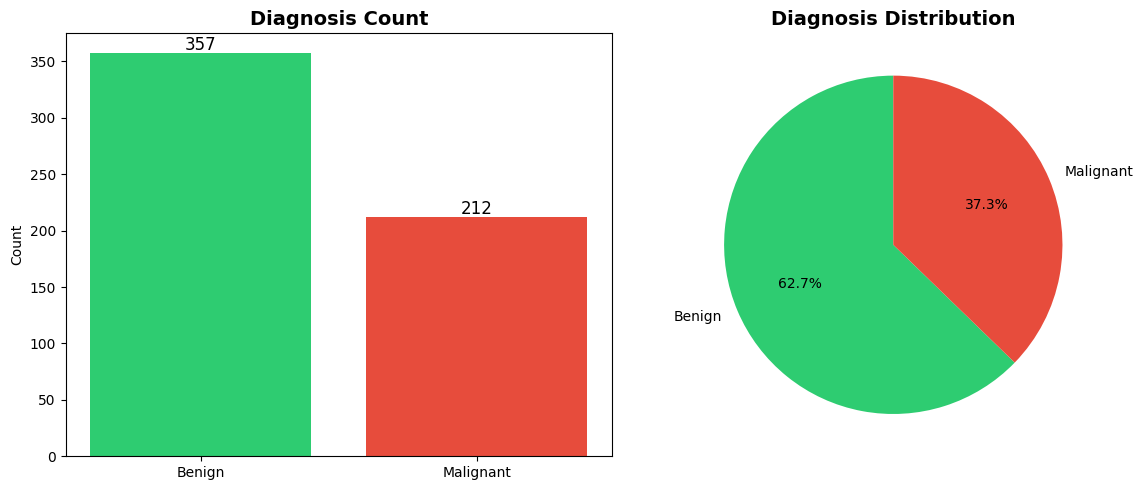

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# bar chart
counts = df['diagnosis'].value_counts()
axes[0].bar(['Benign', 'Malignant'], counts.values,
            color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Diagnosis Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, val in enumerate(counts.values):
    axes[0].text(i, val + 3, str(val), ha='center', fontsize=12)

# pie chart
axes[1].pie(counts.values, labels=['Benign', 'Malignant'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Diagnosis Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/diagnosis_distribution.png', dpi=150)
plt.show()

In [9]:
counts

diagnosis
B    357
M    212
Name: count, dtype: int64

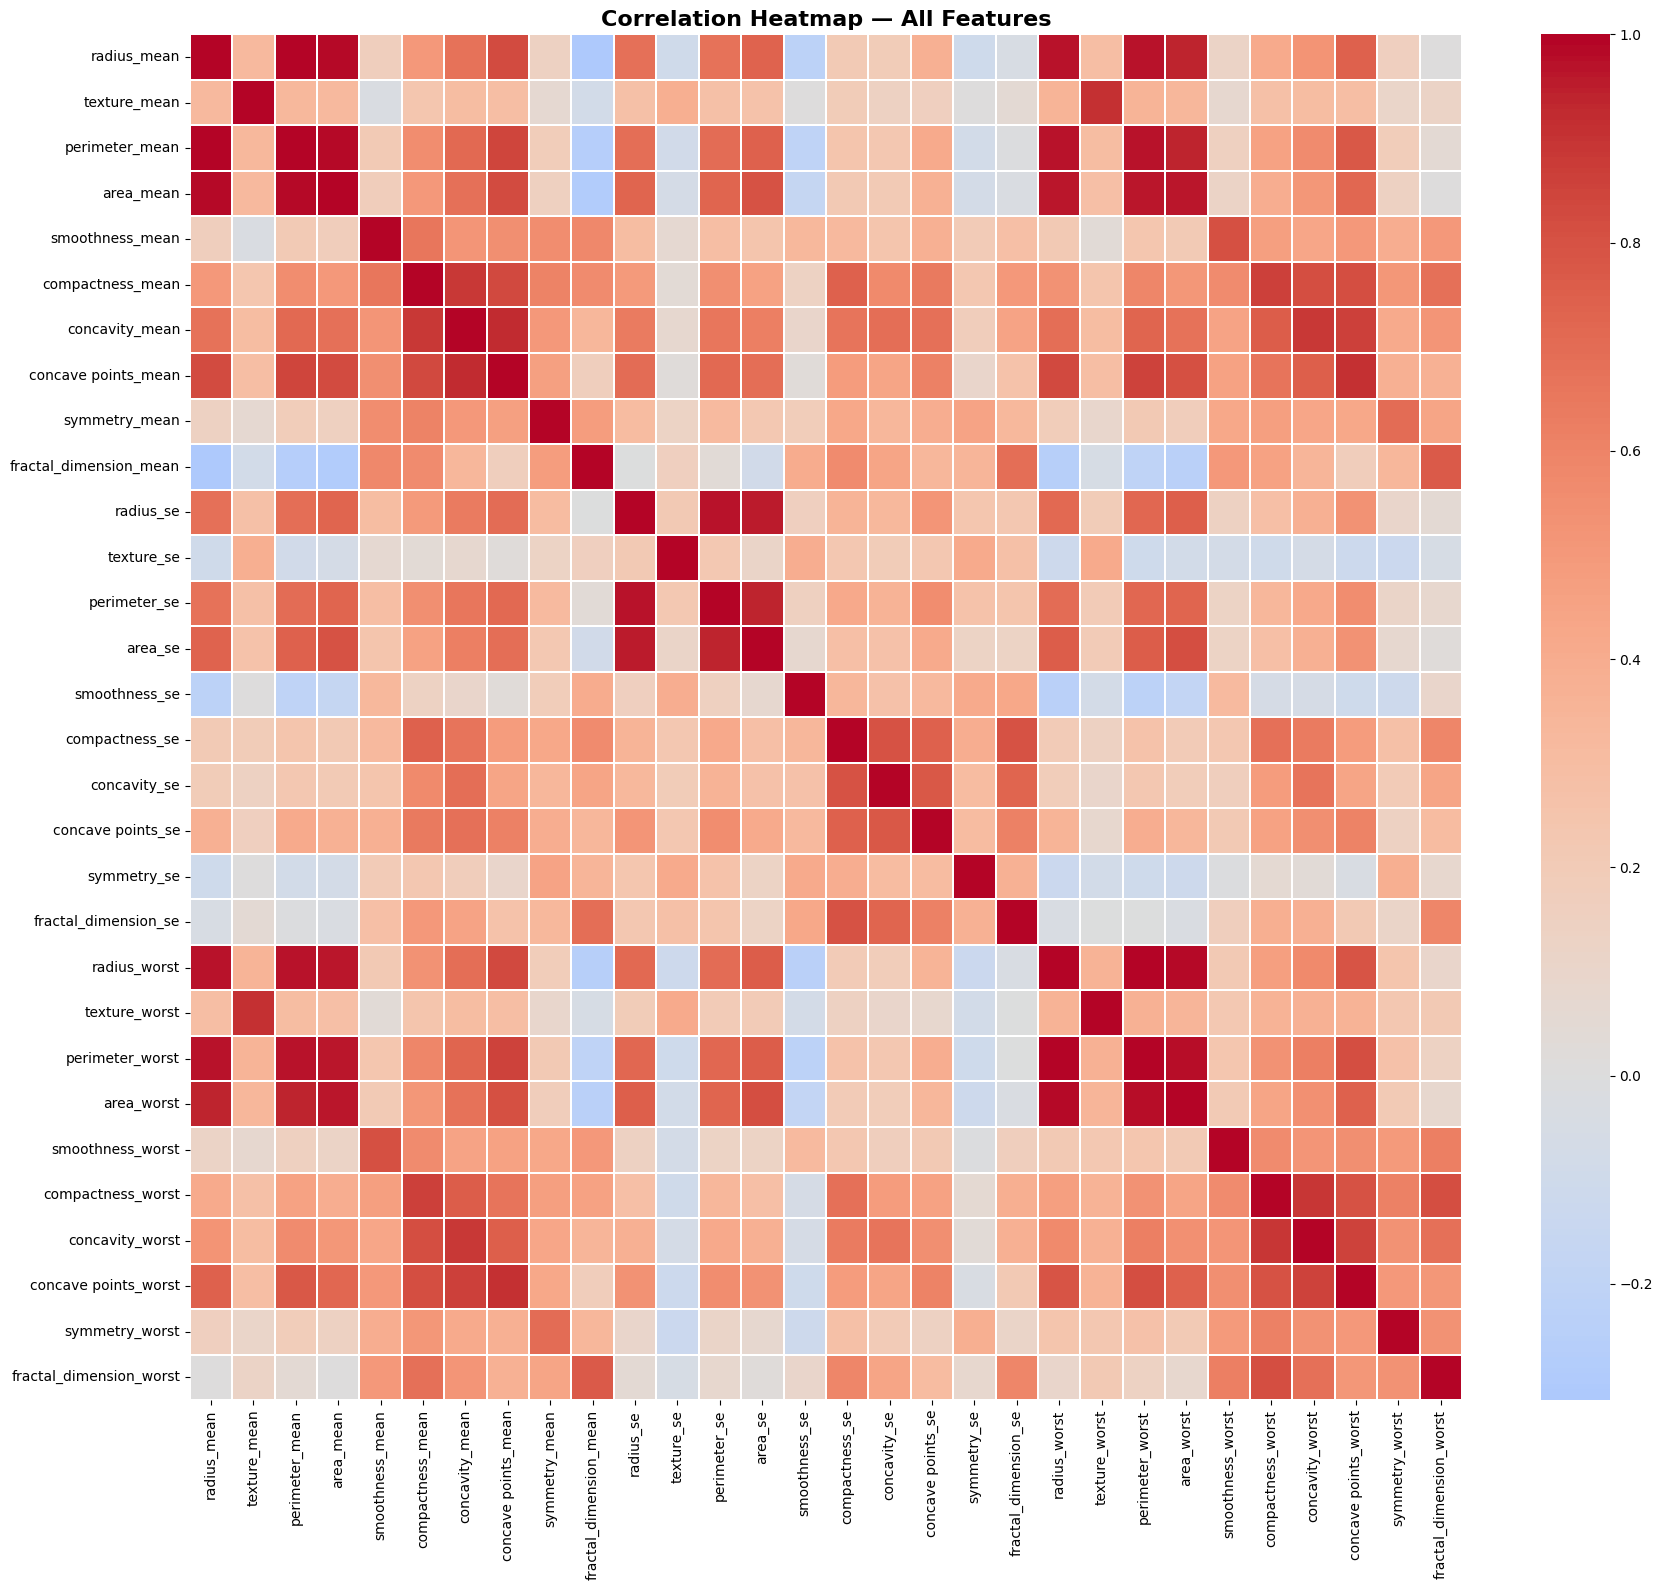

In [10]:
fig, ax = plt.subplots(figsize=(18, 16))

corr = df.drop(columns='diagnosis').corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0,
            linewidths=0.1, ax=ax)

ax.set_title('Correlation Heatmap — All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/correlation_heatmap_all.png', dpi=150)
plt.show()

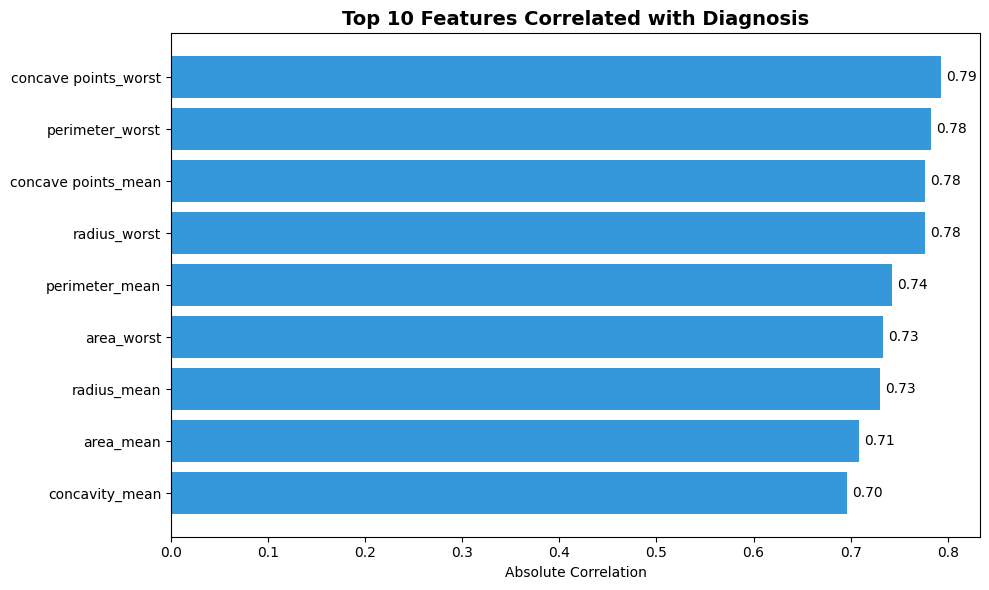

In [11]:
df['diagnosis_encoded'] = df['diagnosis'].map({'M': 1, 'B': 0})
fig, ax = plt.subplots(figsize=(10, 6))

corr_with_diagnosis = df.drop(columns='diagnosis').corrwith(
    df['diagnosis_encoded']).abs().sort_values(ascending=False).head(10)
corr_with_diagnosis = corr_with_diagnosis.drop('diagnosis_encoded')

bars = ax.barh(corr_with_diagnosis.index, corr_with_diagnosis.values,
               color='#3498db')
ax.set_title('Top 10 Features Correlated with Diagnosis', fontsize=14, fontweight='bold')
ax.set_xlabel('Absolute Correlation')
ax.invert_yaxis()

for bar, val in zip(bars, corr_with_diagnosis.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('visualizations/top10_corr_diagnosis.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/2294199520.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/2294199520.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/2294199520.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/229419

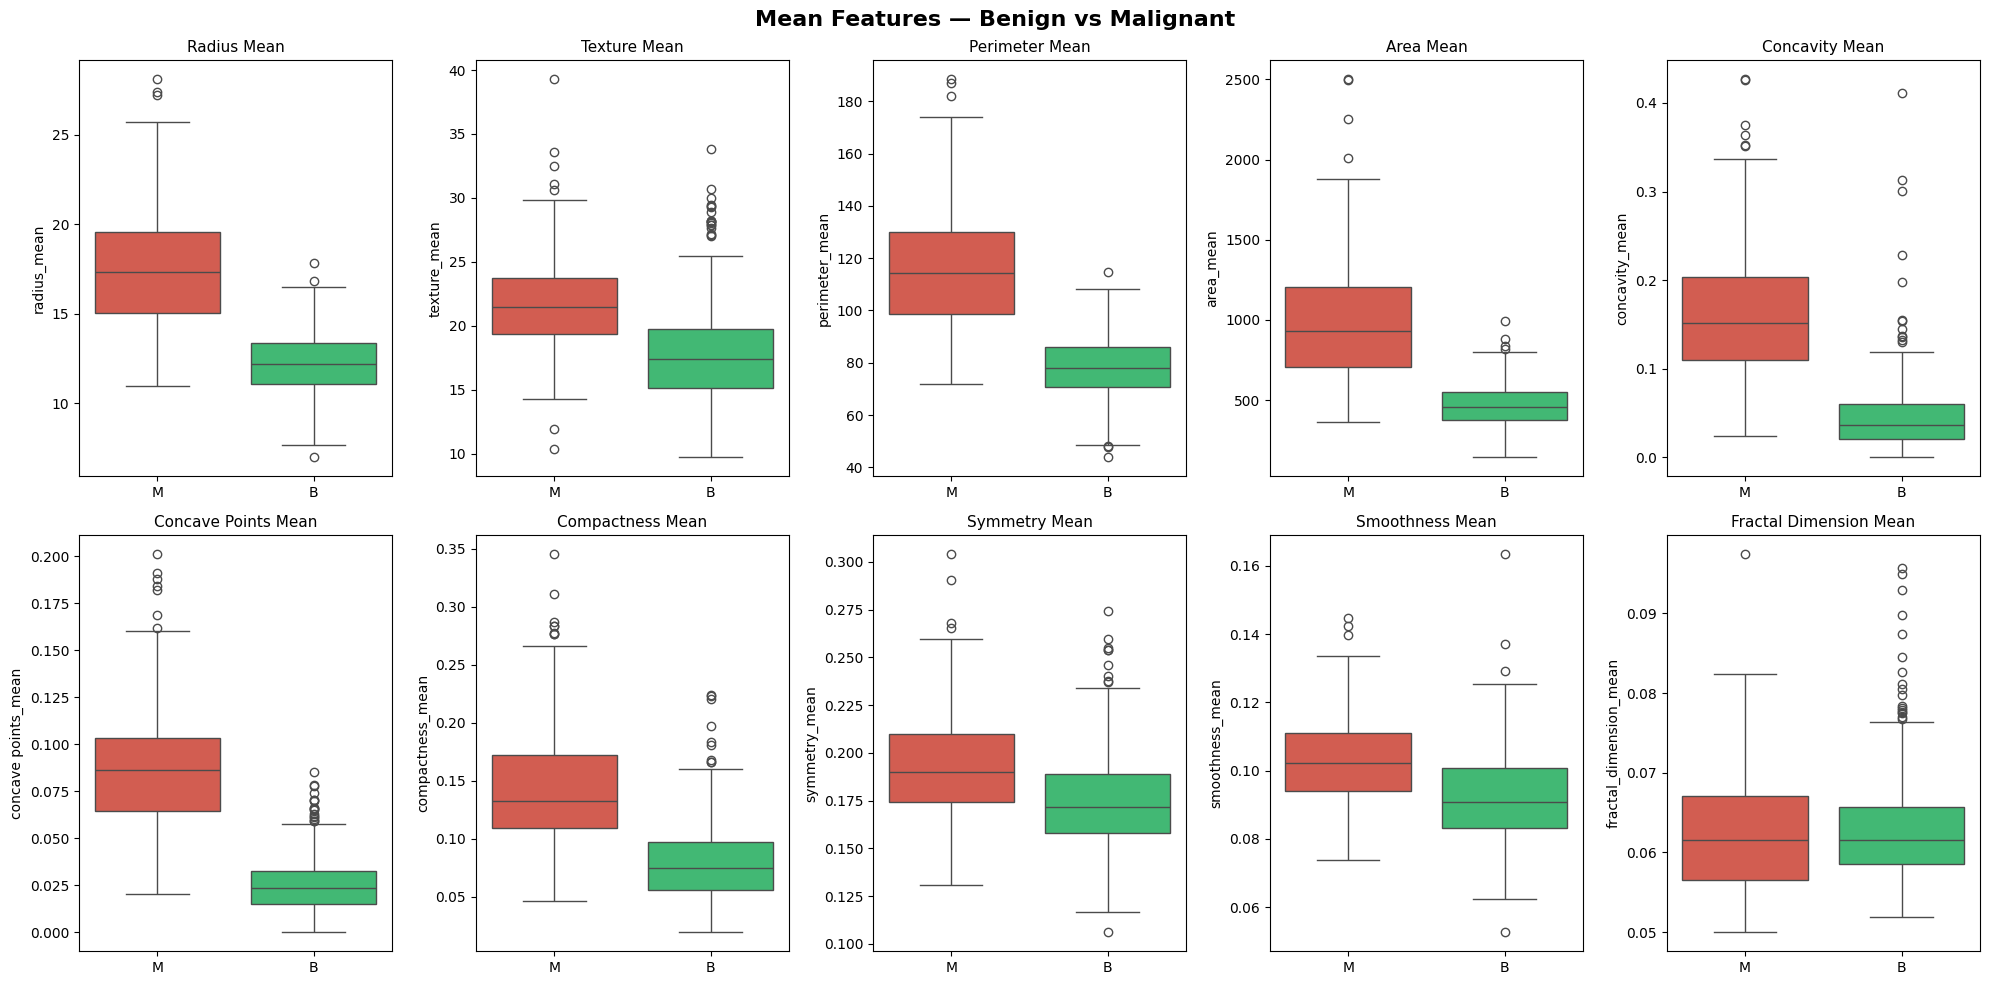

In [12]:
palette = {'M': '#e74c3c', 'B': '#2ecc71'}

mean_features = ['radius_mean', 'texture_mean', 'perimeter_mean',
                 'area_mean', 'concavity_mean', 'concave points_mean',
                 'compactness_mean', 'symmetry_mean',
                 'smoothness_mean', 'fractal_dimension_mean']

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(mean_features):
    sns.boxplot(data=df, x='diagnosis', y=col,
                palette=palette, ax=axes[i])
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xlabel('')

fig.suptitle('Mean Features — Benign vs Malignant', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/boxplots_mean_features.png', dpi=150)
plt.show()

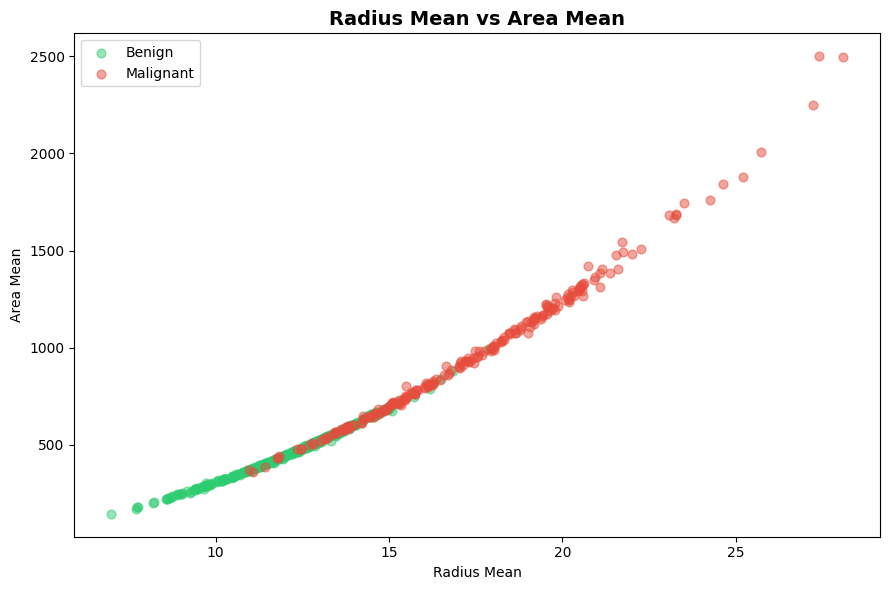

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))

for diagnosis, color in [('B', '#2ecc71'), ('M', "#e74c3c")]:
    subset = df[df['diagnosis'] == diagnosis]
    ax.scatter(subset['radius_mean'], subset['area_mean'],
               c=color, alpha=0.5, s=40,
               label='Benign' if diagnosis == 'B' else 'Malignant')

ax.set_title('Radius Mean vs Area Mean', fontsize=14, fontweight='bold')
ax.set_xlabel('Radius Mean')
ax.set_ylabel('Area Mean')
ax.legend()

plt.tight_layout()
plt.savefig('visualizations/scatter_radius_area.png', dpi=150)
plt.show()

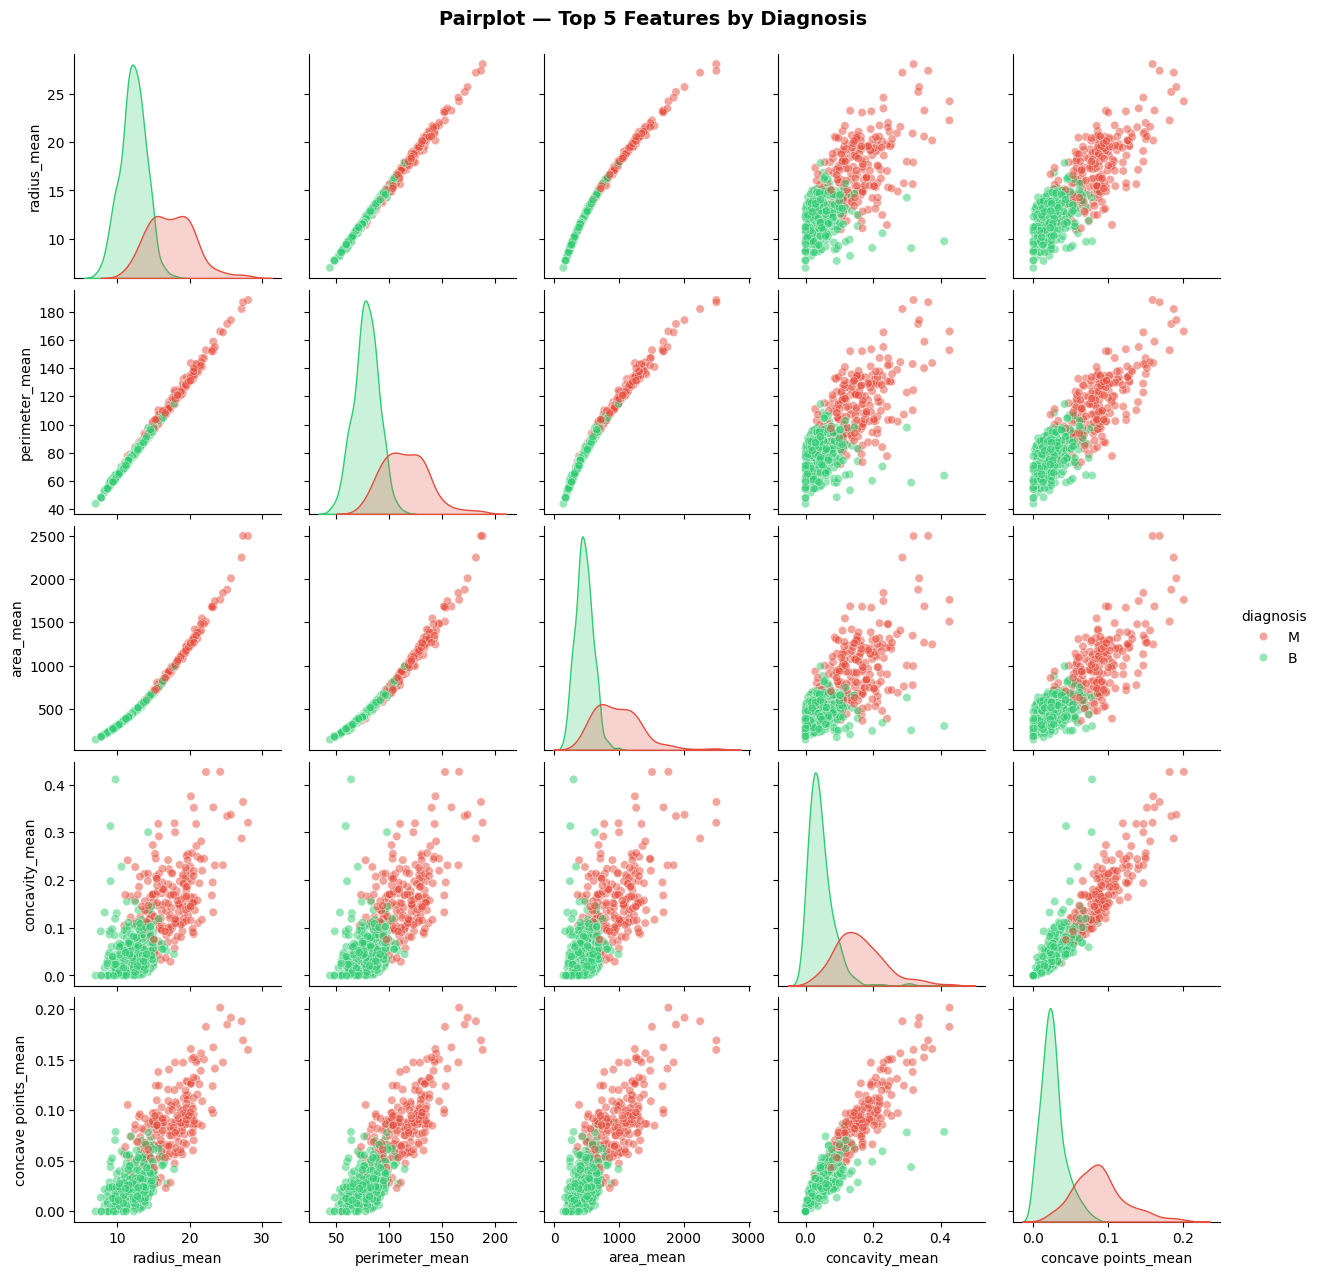

In [14]:
top5 = ['radius_mean', 'perimeter_mean', 'area_mean',
        'concavity_mean', 'concave points_mean', 'diagnosis']

pair = sns.pairplot(df[top5], hue='diagnosis',
                    palette=palette, plot_kws={'alpha': 0.5}, height=2.5)
pair.fig.suptitle('Pairplot — Top 5 Features by Diagnosis',
                  fontsize=14, fontweight='bold', y=1.02)

plt.savefig('visualizations/pairplot_top5.png', dpi=150, bbox_inches='tight')
plt.show()

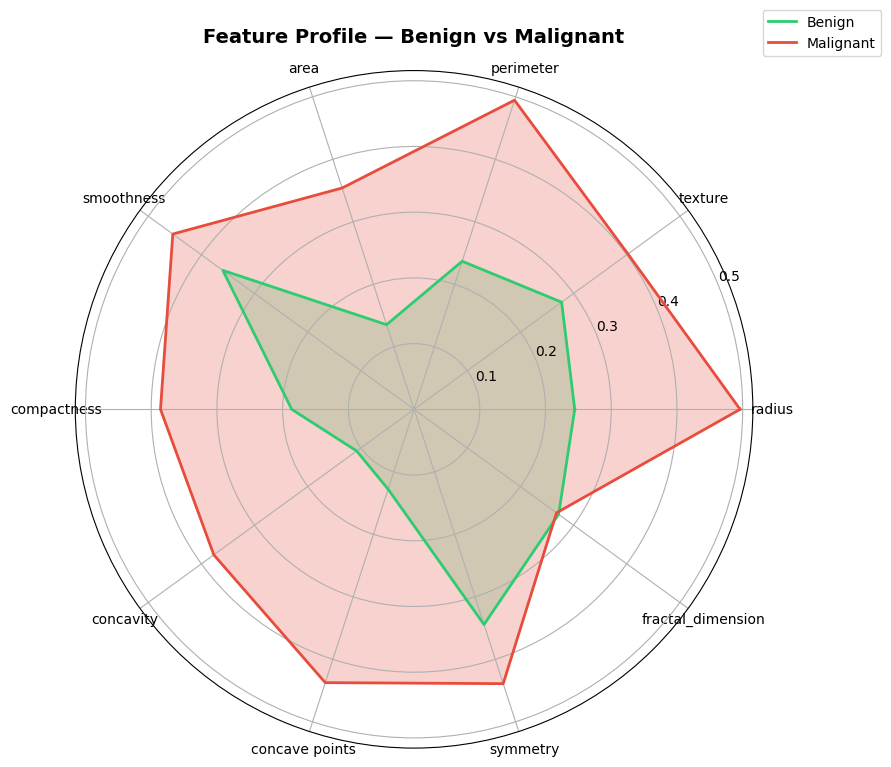

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
mean_features = [c for c in df.columns if '_mean' in c]

# normalize each feature across the whole dataset first
df_scaled = df.copy()
df_scaled[mean_features] = scaler.fit_transform(df[mean_features])

# then take group means
benign_norm = df_scaled[df_scaled['diagnosis']=='B'][mean_features].mean().values
malignant_norm = df_scaled[df_scaled['diagnosis']=='M'][mean_features].mean().values

# rest of radar chart code stays the same
angles = np.linspace(0, 2*np.pi, len(mean_features), endpoint=False).tolist()
benign_norm = np.concatenate((benign_norm, [benign_norm[0]]))
malignant_norm = np.concatenate((malignant_norm, [malignant_norm[0]]))
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.plot(angles, benign_norm, color='#2ecc71', linewidth=2, label='Benign')
ax.fill(angles, benign_norm, color='#2ecc71', alpha=0.25)
ax.plot(angles, malignant_norm, color='#e74c3c', linewidth=2, label='Malignant')
ax.fill(angles, malignant_norm, color='#e74c3c', alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.replace('_mean','') for f in mean_features], fontsize=10)
ax.set_title('Feature Profile — Benign vs Malignant', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.savefig('visualizations/radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
df.groupby('diagnosis')[['symmetry_mean', 'fractal_dimension_mean']].mean()


,symmetry_mean,fractal_dimension_mean
diagnosis,,
B,0.174186,0.062867
M,0.192909,0.062680


/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/3182399612.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/3182399612.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/3182399612.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/318239

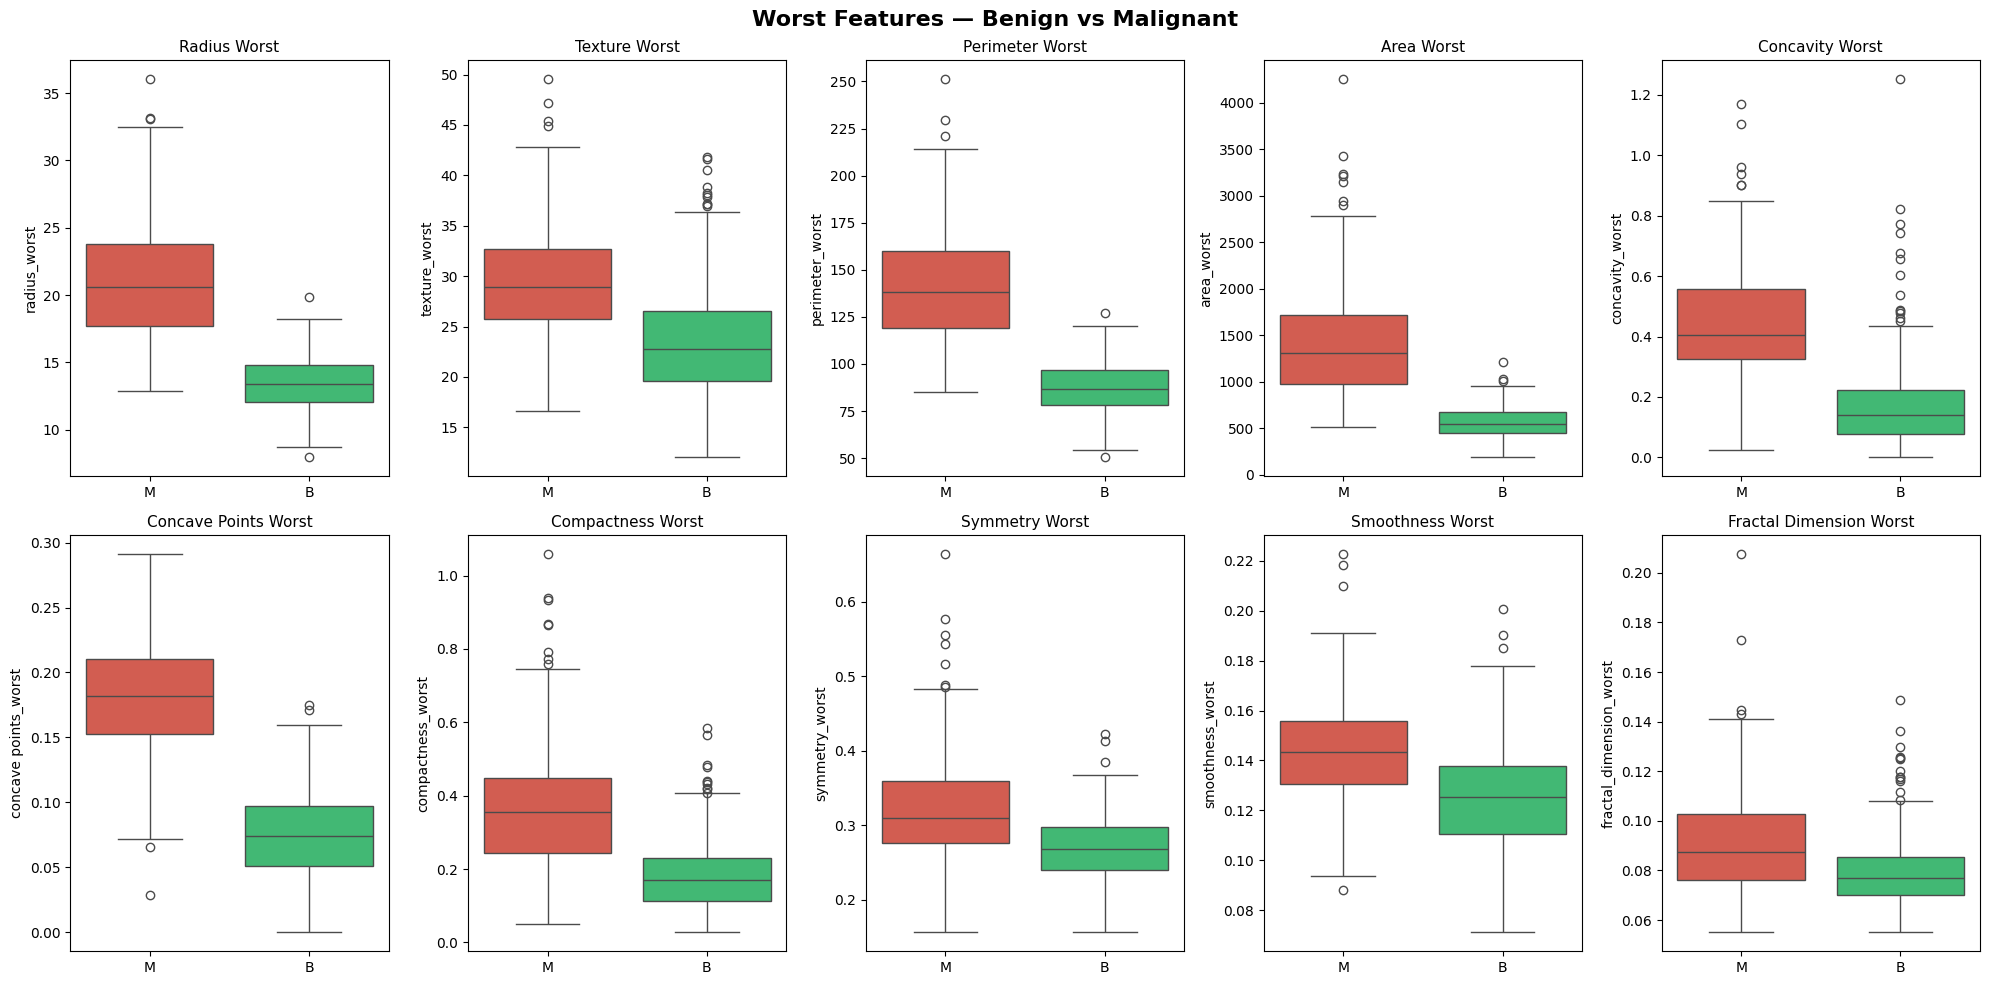

In [17]:
worst_features = ['radius_worst', 'texture_worst', 'perimeter_worst',
                  'area_worst', 'concavity_worst', 'concave points_worst',
                  'compactness_worst', 'symmetry_worst',
                  'smoothness_worst', 'fractal_dimension_worst']

fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(worst_features):
    sns.boxplot(data=df, x='diagnosis', y=col,
                palette=palette, ax=axes[i])
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xlabel('')

fig.suptitle('Worst Features — Benign vs Malignant', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/boxplots_worst_features.png', dpi=150)
plt.show()

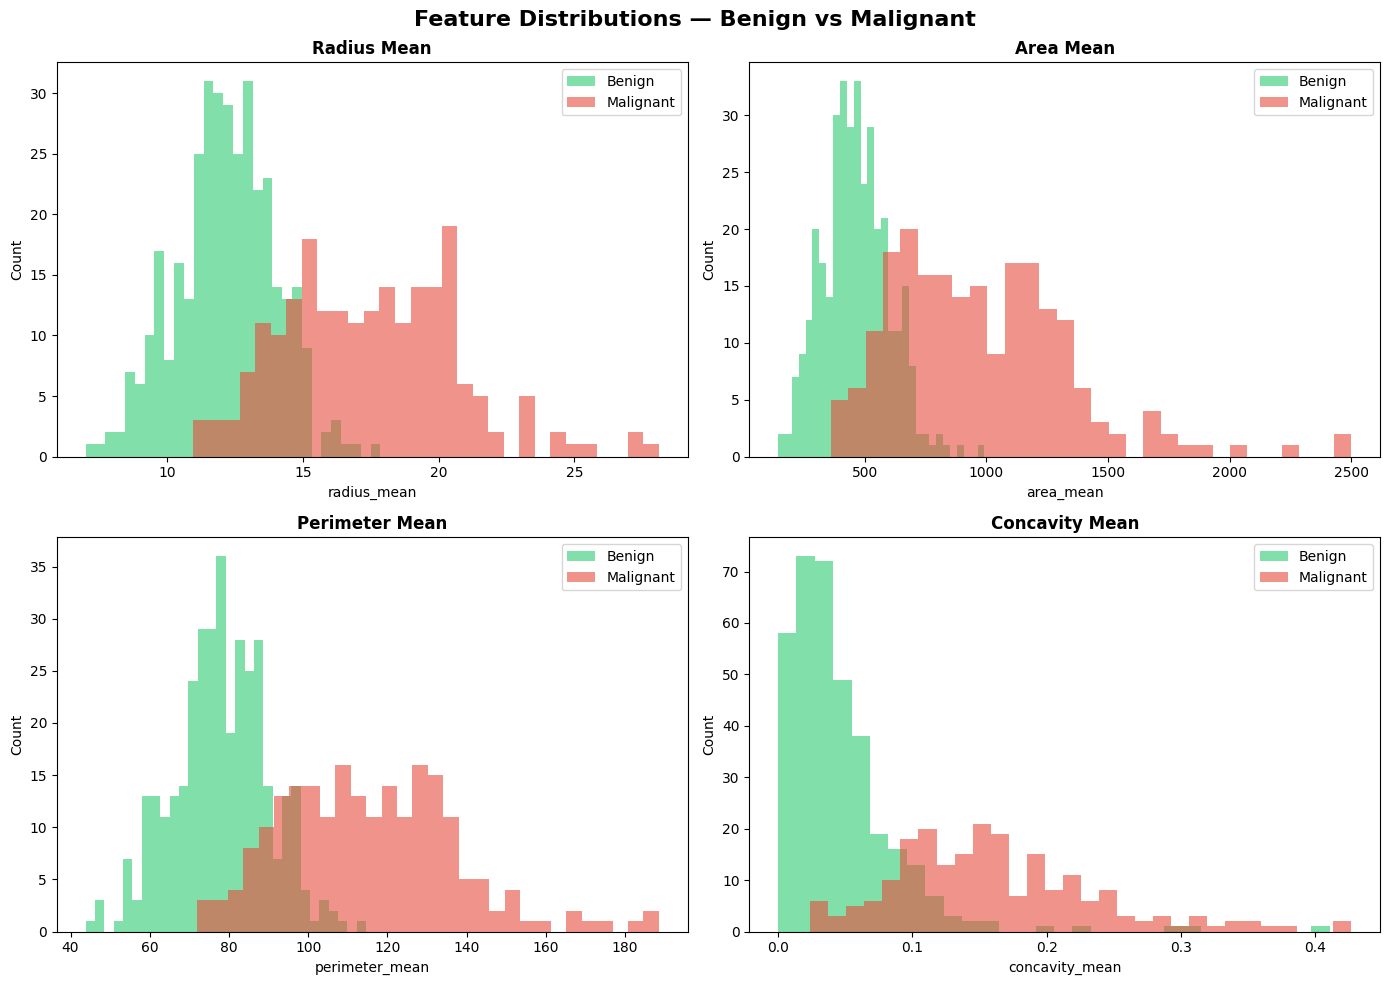

In [18]:
key_features = ['radius_mean', 'area_mean', 'perimeter_mean', 'concavity_mean']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    axes[i].hist(df[df['diagnosis']=='B'][col], bins=30,
                 alpha=0.6, color='#2ecc71', label='Benign')
    axes[i].hist(df[df['diagnosis']=='M'][col], bins=30,
                 alpha=0.6, color='#e74c3c', label='Malignant')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

fig.suptitle('Feature Distributions — Benign vs Malignant', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/histograms_key_features.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/2643200746.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/2643200746.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/2643200746.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/

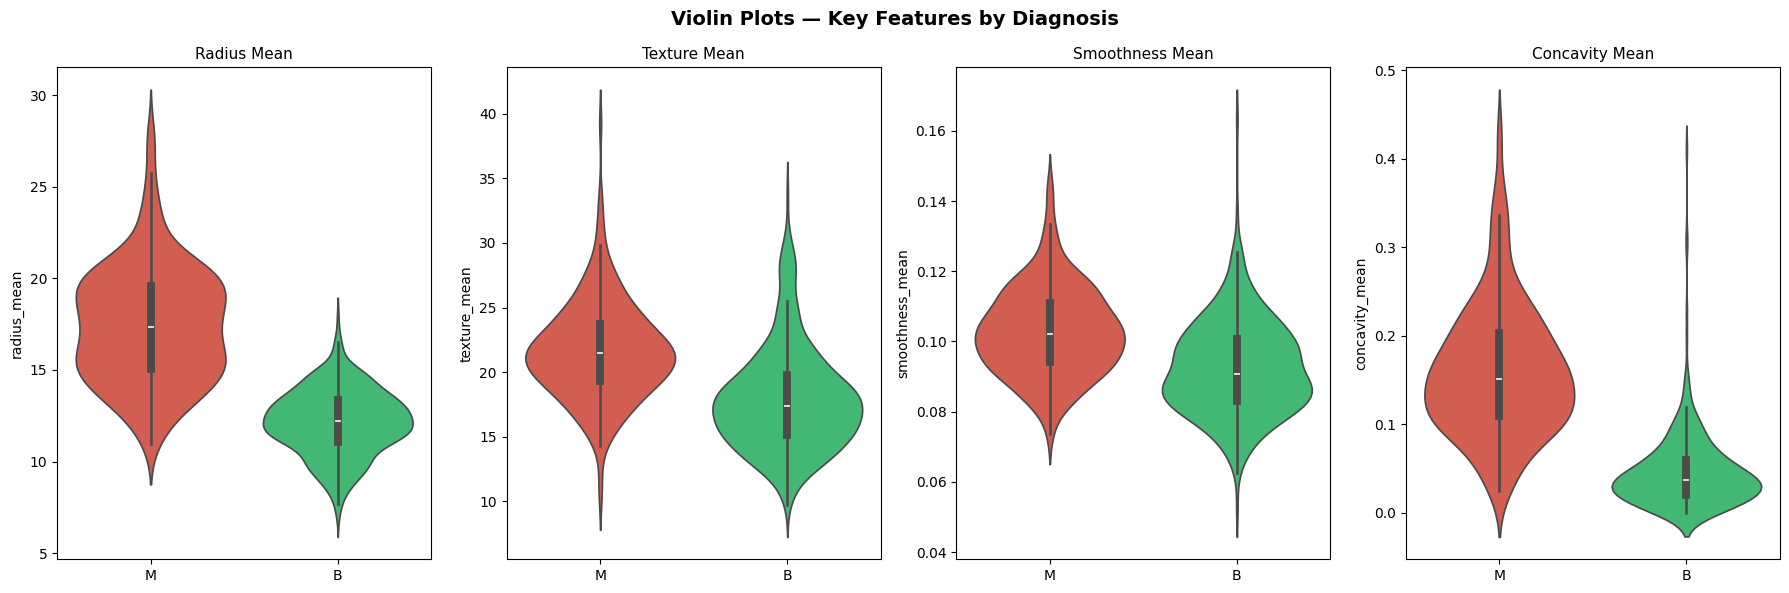

In [19]:
violin_features = ['radius_mean', 'texture_mean', 'smoothness_mean', 'concavity_mean']

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, col in enumerate(violin_features):
    sns.violinplot(data=df, x='diagnosis', y=col,
                   palette=palette, ax=axes[i])
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xlabel('')

fig.suptitle('Violin Plots — Key Features by Diagnosis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/violin_plots.png', dpi=150)
plt.show()

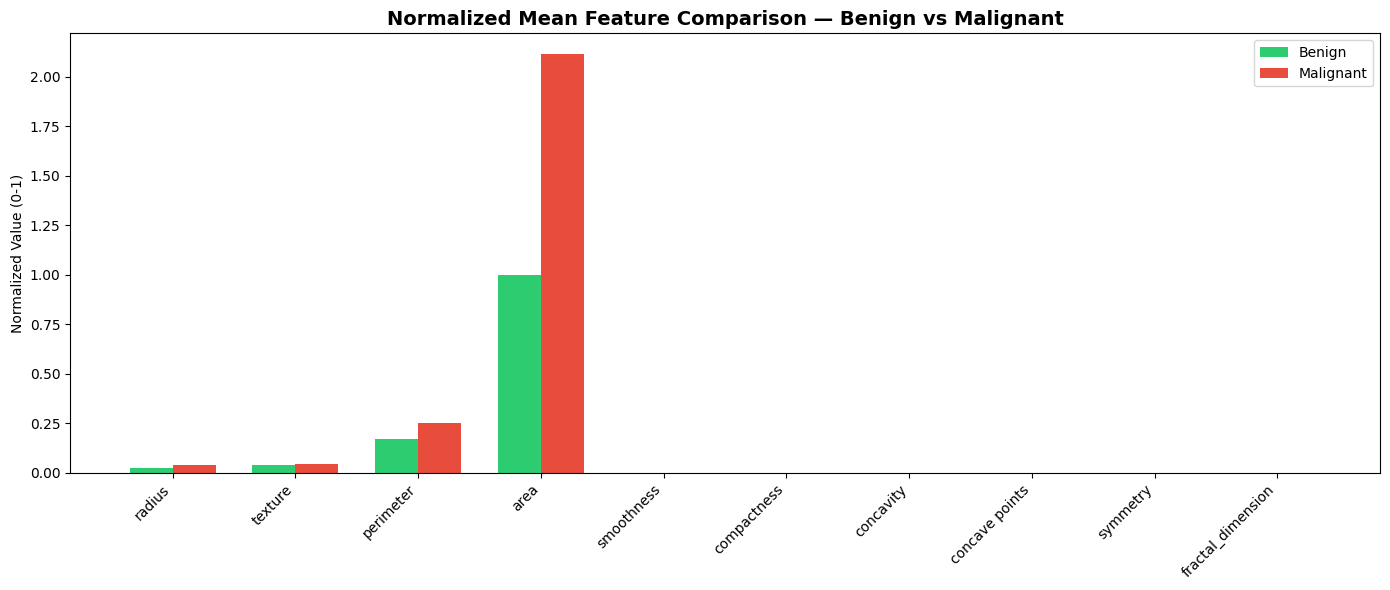

In [20]:
fig, ax = plt.subplots(figsize=(14, 6))

mean_features = [c for c in df.columns if '_mean' in c]
benign_means = df[df['diagnosis']=='B'][mean_features].mean()
malignant_means = df[df['diagnosis']=='M'][mean_features].mean()

# normalize to 0-1 for fair comparison
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
benign_norm = scaler.fit_transform(benign_means.values.reshape(-1,1)).flatten()
malignant_norm = scaler.transform(malignant_means.values.reshape(-1,1)).flatten()

x = np.arange(len(mean_features))
width = 0.35

ax.bar(x - width/2, benign_norm, width, color='#2ecc71', label='Benign')
ax.bar(x + width/2, malignant_norm, width, color='#e74c3c', label='Malignant')

ax.set_xticks(x)
ax.set_xticklabels([f.replace('_mean','') for f in mean_features], rotation=45, ha='right')
ax.set_title('Normalized Mean Feature Comparison — Benign vs Malignant',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Normalized Value (0-1)')
ax.legend()

plt.tight_layout()
plt.savefig('visualizations/feature_comparison_normalized.png', dpi=150)
plt.show()

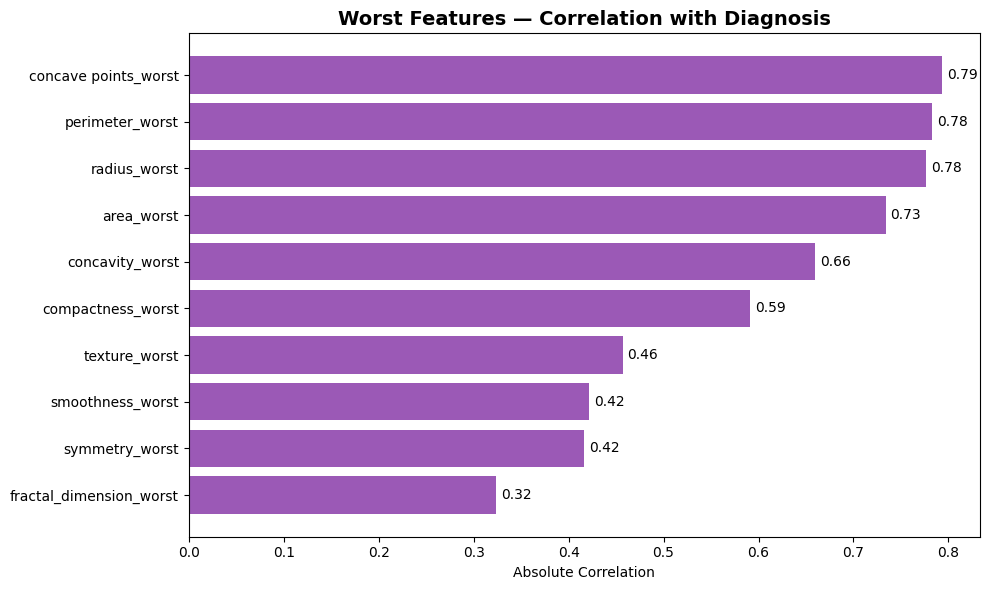

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))

worst_corr = df[[c for c in df.columns if '_worst' in c]].corrwith(
    df['diagnosis_encoded']).abs().sort_values(ascending=False)

bars = ax.barh(worst_corr.index, worst_corr.values, color='#9b59b6')
ax.set_title('Worst Features — Correlation with Diagnosis', fontsize=14, fontweight='bold')
ax.set_xlabel('Absolute Correlation')
ax.invert_yaxis()

for bar, val in zip(bars, worst_corr.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('visualizations/worst_features_corr.png', dpi=150)
plt.show()

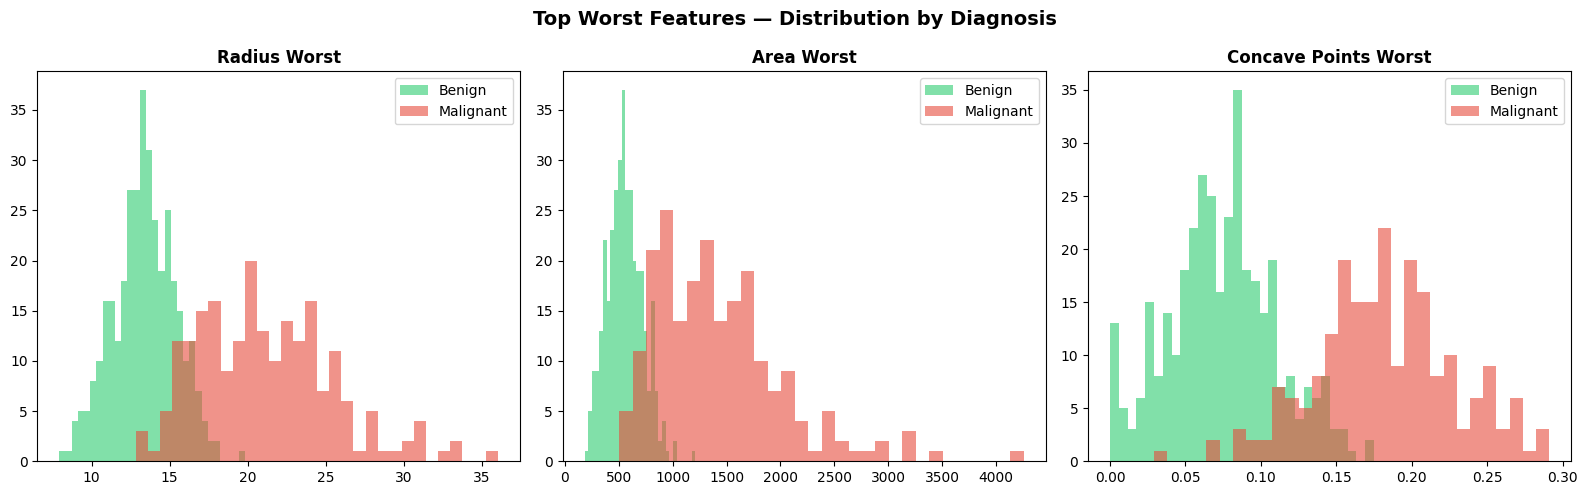

In [22]:
top3_worst = ['radius_worst', 'area_worst', 'concave points_worst']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(top3_worst):
    axes[i].hist(df[df['diagnosis']=='B'][col], bins=30,
                 alpha=0.6, color='#2ecc71', label='Benign')
    axes[i].hist(df[df['diagnosis']=='M'][col], bins=30,
                 alpha=0.6, color='#e74c3c', label='Malignant')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[i].legend()

fig.suptitle('Top Worst Features — Distribution by Diagnosis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/top3_worst_dist.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/1650796851.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f.replace('_mean','').replace('_se','').replace('_worst','')
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/1650796851.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f.replace('_mean','').replace('_se','').replace('_worst','')
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/1650796851.py:16: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f.replace('_mean','').replace('_se','').replace('_worst','')


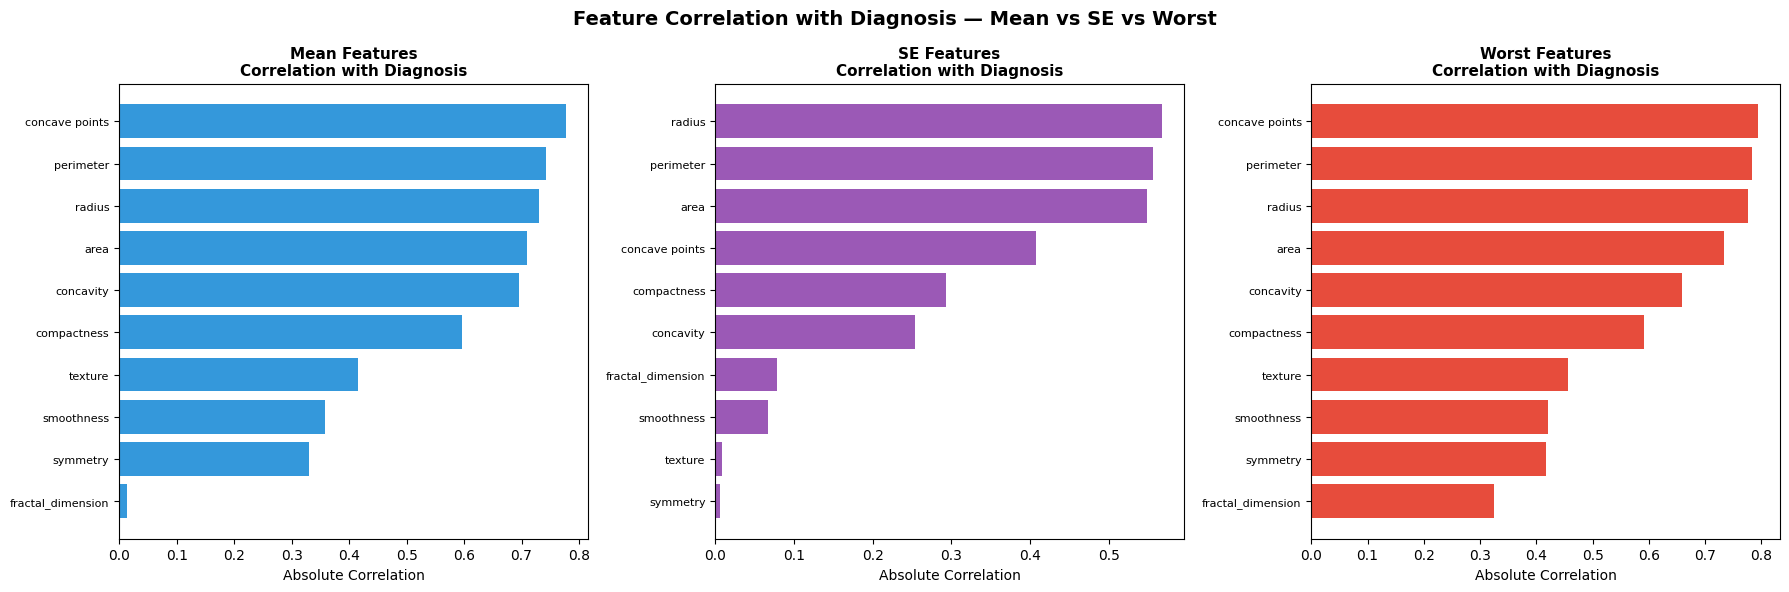

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

categories_map = {
    'Mean Features': [c for c in df.columns if '_mean' in c],
    'SE Features':   [c for c in df.columns if '_se' in c],
    'Worst Features':[c for c in df.columns if '_worst' in c]
}

for ax, (title, features) in zip(axes, categories_map.items()):
    corr = df[features].corrwith(df['diagnosis_encoded']).abs().sort_values(ascending=False)
    ax.barh(corr.index, corr.values,
            color='#3498db' if 'Mean' in title else '#9b59b6' if 'SE' in title else '#e74c3c')
    ax.set_title(f'{title}\nCorrelation with Diagnosis', fontsize=11, fontweight='bold')
    ax.set_xlabel('Absolute Correlation')
    ax.invert_yaxis()
    ax.set_yticklabels([f.replace('_mean','').replace('_se','').replace('_worst','')
                        for f in corr.index], fontsize=8)

fig.suptitle('Feature Correlation with Diagnosis — Mean vs SE vs Worst',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/corr_three_categories.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/2163618773.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/2163618773.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df, x='diagnosis', y=col,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/2163618773.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=df, x='diagnosis', y=col,


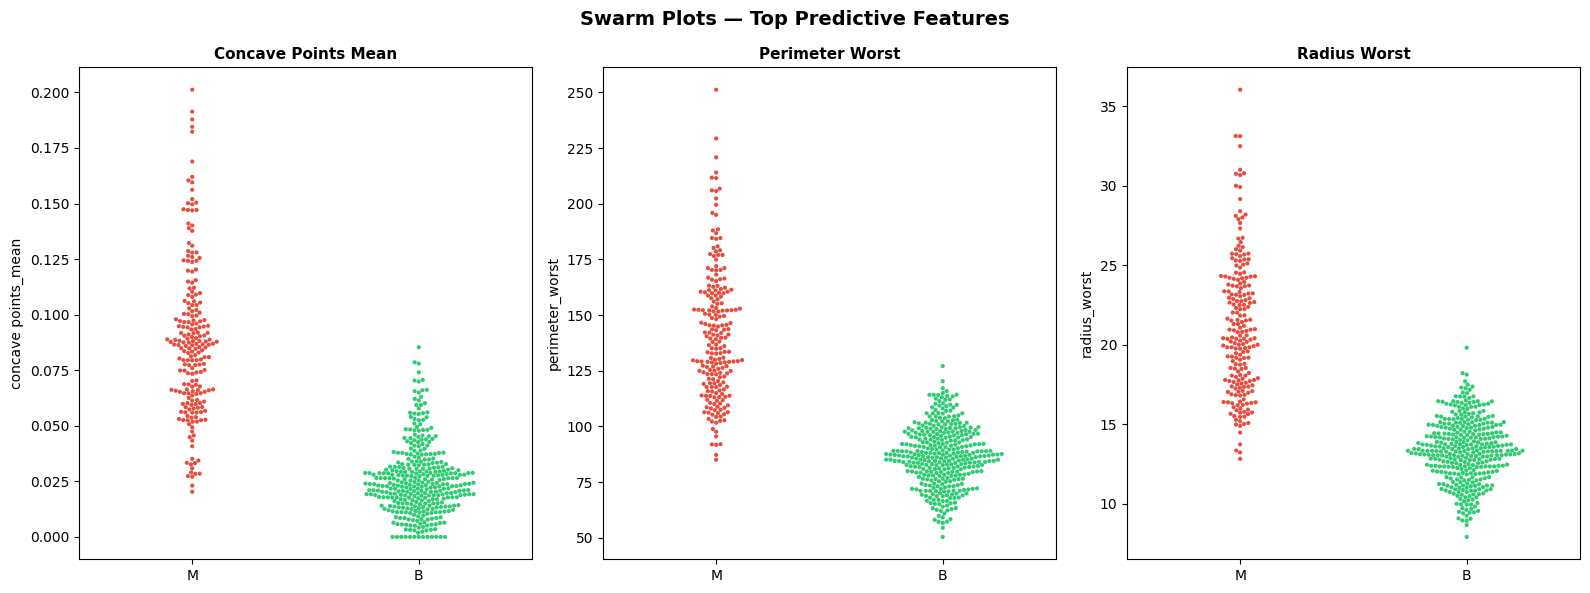

In [24]:
top3 = ['concave points_mean', 'perimeter_worst', 'radius_worst']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, col in enumerate(top3):
    sns.swarmplot(data=df, x='diagnosis', y=col,
                  palette=palette, ax=axes[i], size=3)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

fig.suptitle('Swarm Plots — Top Predictive Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/swarm_plots.png', dpi=150)
plt.show()

In [25]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'diagnosis_encoded'],
      dtype='object')

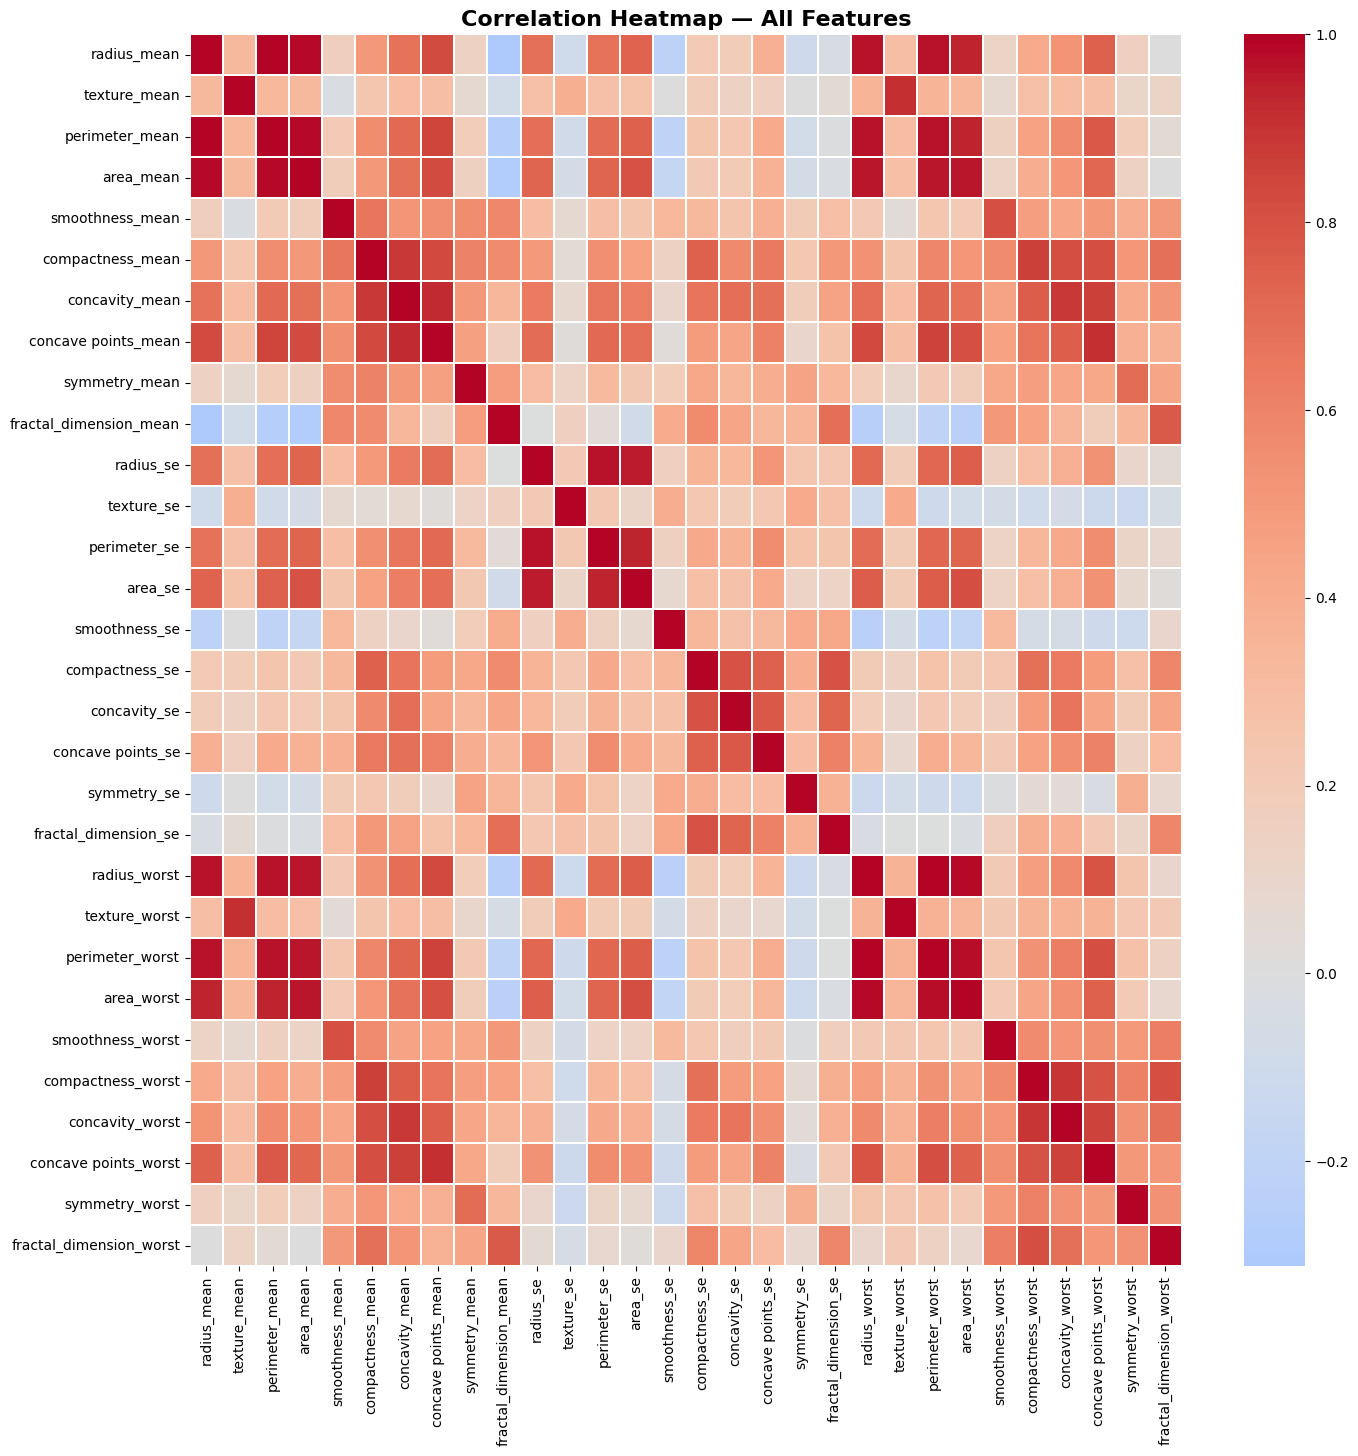

In [26]:
fig, ax = plt.subplots(figsize=(16,16))

correlation = df.drop(columns=['diagnosis','diagnosis_encoded']).corr()

sns.heatmap(correlation, annot=False,center=0, linewidths= 0.1, cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap — All Features', fontsize=16, fontweight='bold')

plt.show()                      
                    

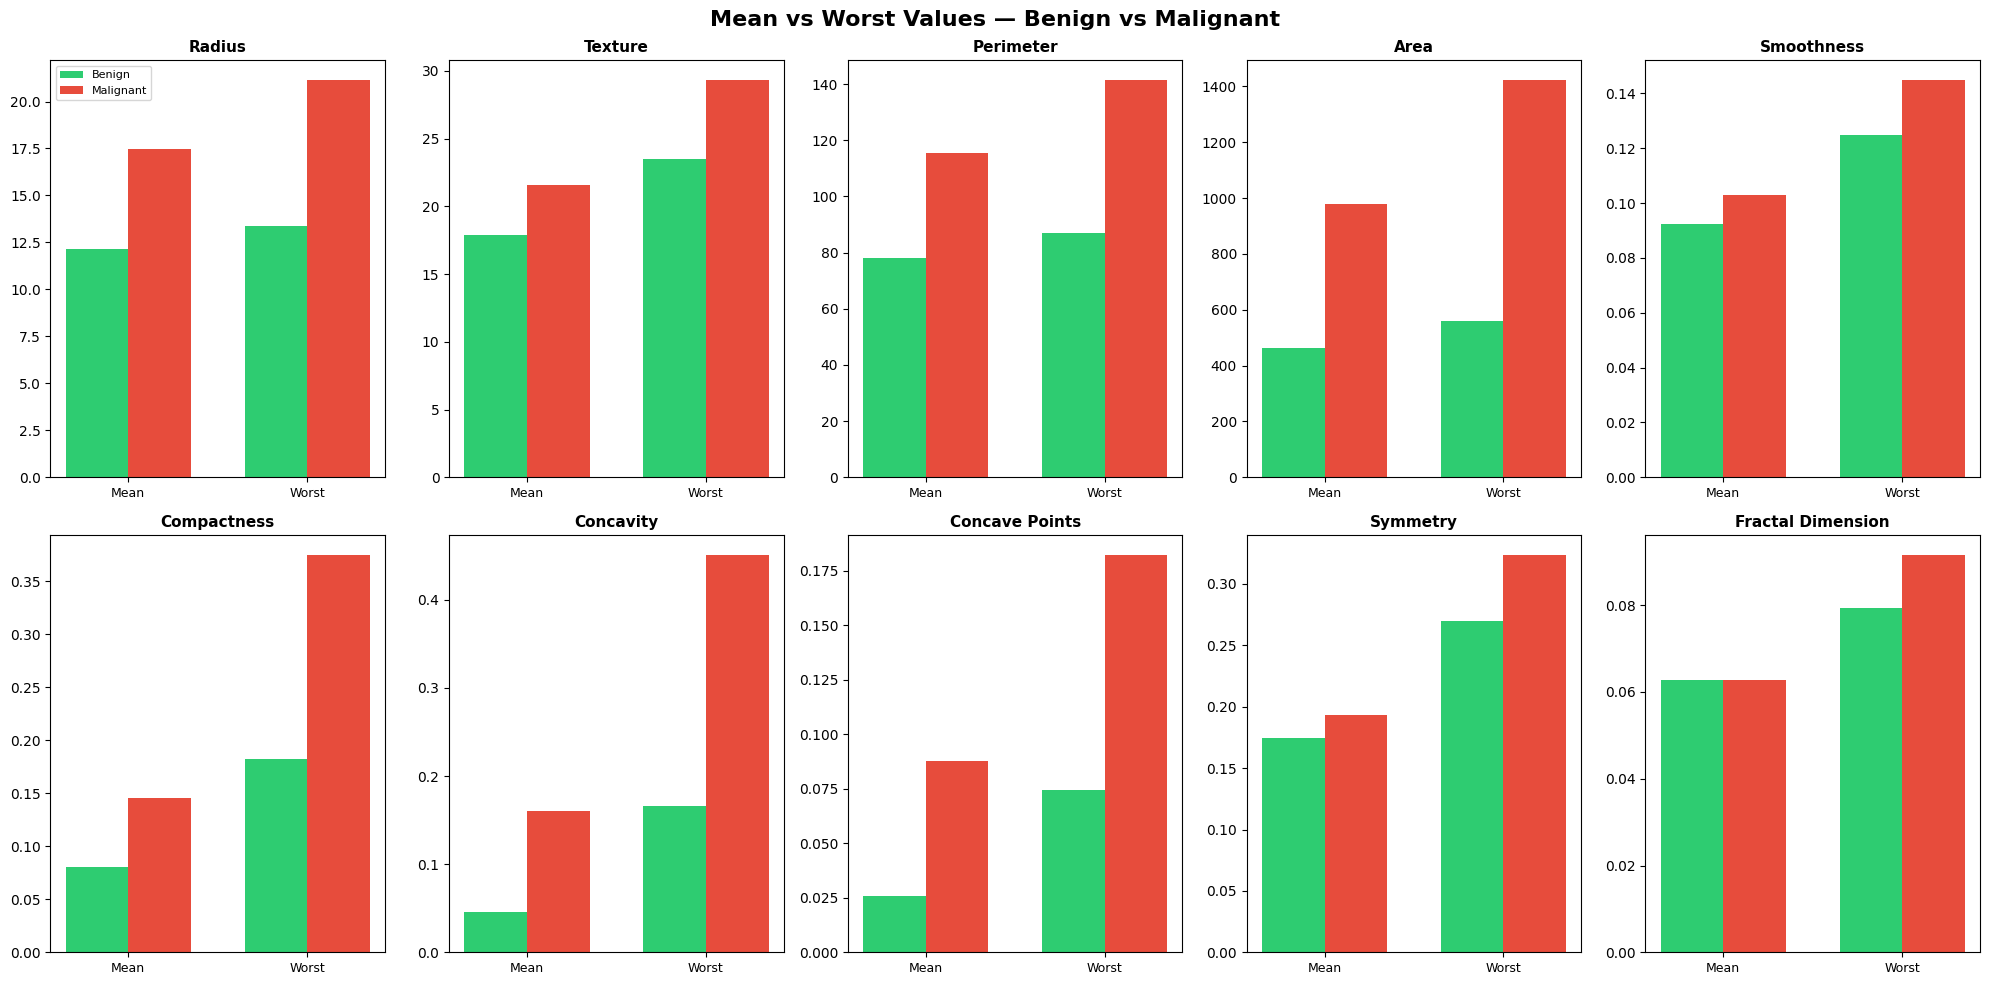

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

feature_pairs = [
    ('radius_mean', 'radius_worst'),
    ('texture_mean', 'texture_worst'),
    ('perimeter_mean', 'perimeter_worst'),
    ('area_mean', 'area_worst'),
    ('smoothness_mean', 'smoothness_worst'),
    ('compactness_mean', 'compactness_worst'),
    ('concavity_mean', 'concavity_worst'),
    ('concave points_mean', 'concave points_worst'),
    ('symmetry_mean', 'symmetry_worst'),
    ('fractal_dimension_mean', 'fractal_dimension_worst')
]

for i, (mean_col, worst_col) in enumerate(feature_pairs):
    feature_name = mean_col.replace('_mean', '')
    
    benign_mean = df[df['diagnosis']=='B'][mean_col].mean()
    malignant_mean = df[df['diagnosis']=='M'][mean_col].mean()
    benign_worst = df[df['diagnosis']=='B'][worst_col].mean()
    malignant_worst = df[df['diagnosis']=='M'][worst_col].mean()
    
    x = np.arange(2)
    width = 0.35
    
    axes[i].bar(x - width/2, [benign_mean, benign_worst],
                width, color='#2ecc71', label='Benign')
    axes[i].bar(x + width/2, [malignant_mean, malignant_worst],
                width, color='#e74c3c', label='Malignant')
    
    axes[i].set_title(feature_name.replace('_', ' ').title(),
                      fontsize=11, fontweight='bold')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(['Mean', 'Worst'], fontsize=9)
    if i == 0:
        axes[i].legend(fontsize=8)

fig.suptitle('Mean vs Worst Values — Benign vs Malignant',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/mean_vs_worst_comparison.png', dpi=150)
plt.show()

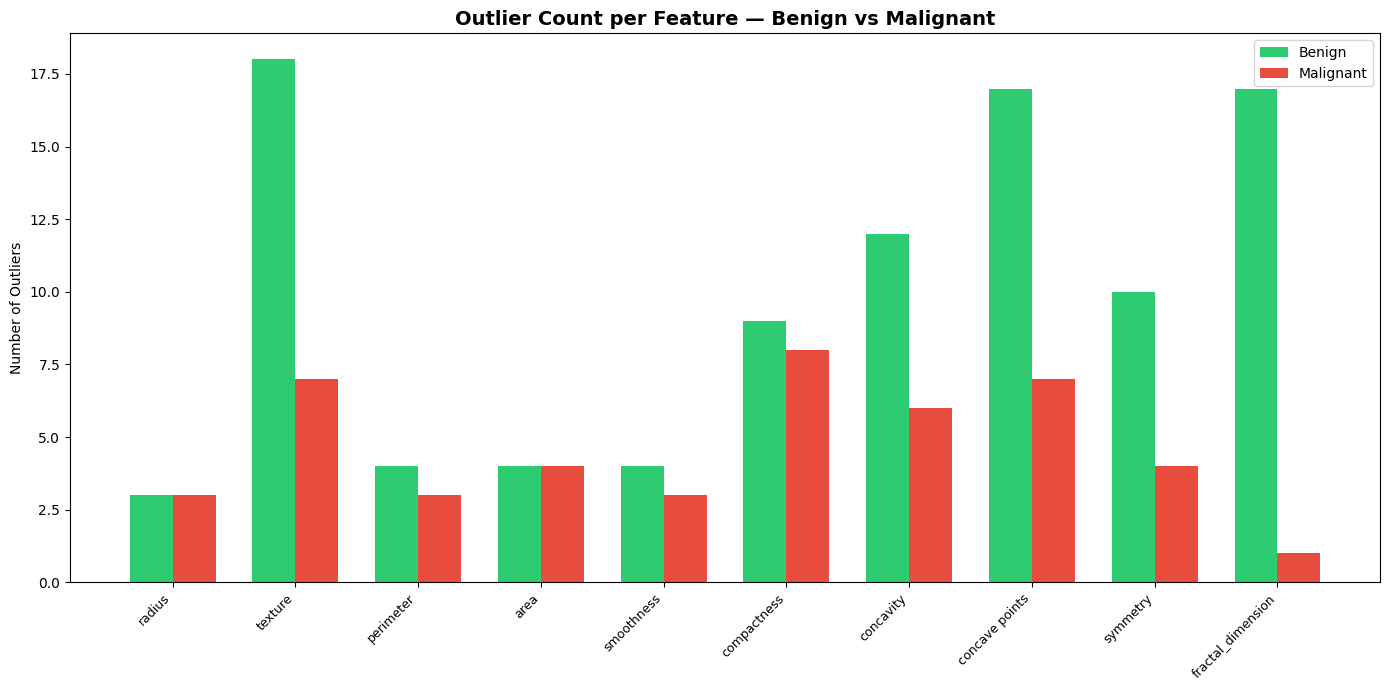

In [28]:
fig, ax = plt.subplots(figsize=(14, 7))

mean_features = [c for c in df.columns if '_mean' in c]

def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

benign_outliers = df[df['diagnosis']=='B'][mean_features].apply(count_outliers)
malignant_outliers = df[df['diagnosis']=='M'][mean_features].apply(count_outliers)

x = np.arange(len(mean_features))
width = 0.35

ax.bar(x - width/2, benign_outliers.values, width,
       color='#2ecc71', label='Benign')
ax.bar(x + width/2, malignant_outliers.values, width,
       color='#e74c3c', label='Malignant')

ax.set_xticks(x)
ax.set_xticklabels([f.replace('_mean', '') for f in mean_features],
                   rotation=45, ha='right', fontsize=9)
ax.set_title('Outlier Count per Feature — Benign vs Malignant',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Outliers')
ax.legend()

plt.tight_layout()
plt.savefig('visualizations/outlier_analysis.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/605232074.py:29: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f.replace('_mean', '') for f in scores.index])


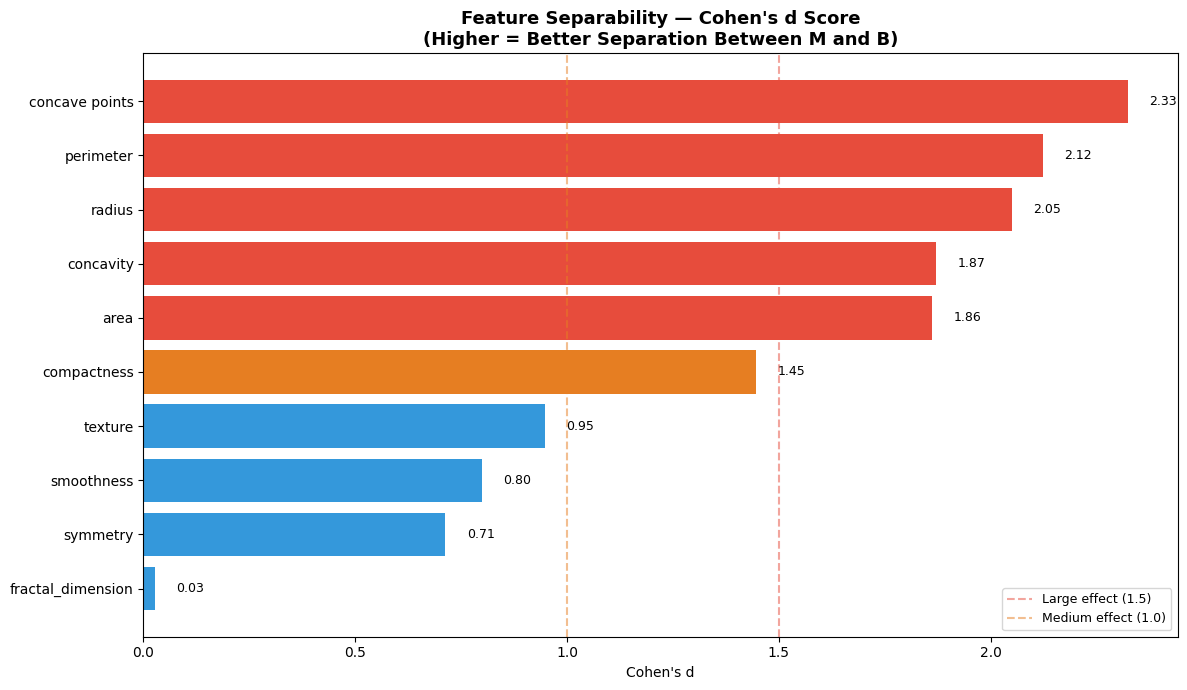

In [29]:
fig, ax = plt.subplots(figsize=(12, 7))

from scipy import stats

mean_features = [c for c in df.columns if '_mean' in c]
benign = df[df['diagnosis']=='B']
malignant = df[df['diagnosis']=='M']

# calculate Cohen's d — measures separation between two groups
def cohens_d(group1, group2):
    diff = abs(group1.mean() - group2.mean())
    pooled_std = np.sqrt((group1.std()**2 + group2.std()**2) / 2)
    return diff / pooled_std

scores = {}
for col in mean_features:
    scores[col] = cohens_d(malignant[col], benign[col])

scores = pd.Series(scores).sort_values(ascending=False)

colors = ['#e74c3c' if v > 1.5 else '#e67e22' if v > 1.0 else '#3498db'
          for v in scores.values]

bars = ax.barh(scores.index, scores.values, color=colors)
ax.set_title("Feature Separability — Cohen's d Score\n(Higher = Better Separation Between M and B)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Cohen's d")
ax.invert_yaxis()
ax.set_yticklabels([f.replace('_mean', '') for f in scores.index])
ax.axvline(x=1.5, color='#e74c3c', linestyle='--', alpha=0.5, label='Large effect (1.5)')
ax.axvline(x=1.0, color='#e67e22', linestyle='--', alpha=0.5, label='Medium effect (1.0)')
ax.legend(fontsize=9)

for bar, val in zip(bars, scores.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('visualizations/cohens_d_separability.png', dpi=150)
plt.show()

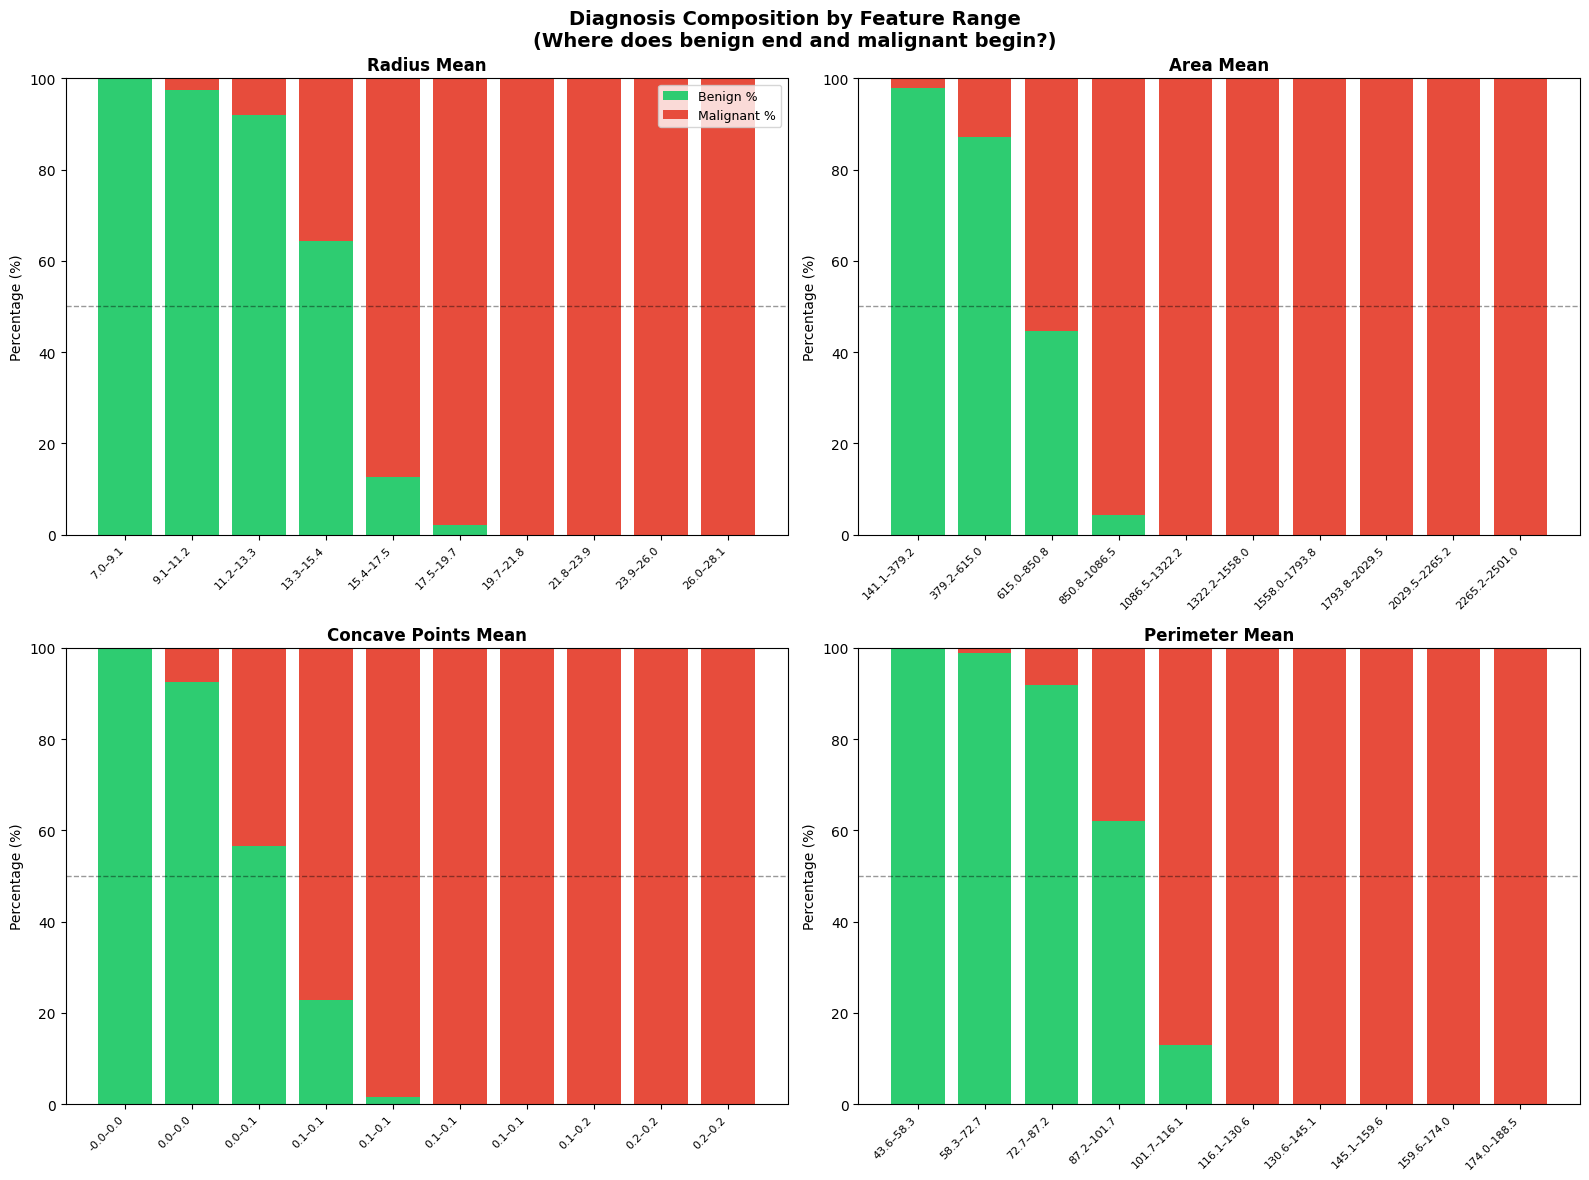

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

features = ['radius_mean', 'area_mean', 'concave points_mean', 'perimeter_mean']

for i, feature in enumerate(features):
    # create 10 equal-width bins
    df['bin'] = pd.cut(df[feature], bins=10)
    
    # count M and B per bin
    grouped = df.groupby(['bin', 'diagnosis']).size().unstack(fill_value=0)
    
    # calculate malignant percentage per bin
    grouped['total'] = grouped.sum(axis=1)
    grouped['pct_malignant'] = grouped['M'] / grouped['total'] * 100
    grouped['pct_benign'] = grouped['B'] / grouped['total'] * 100
    
    bin_labels = [f'{b.left:.1f}–{b.right:.1f}' for b in grouped.index]
    x = np.arange(len(bin_labels))
    
    axes[i].bar(x, grouped['pct_benign'], color='#2ecc71', label='Benign %')
    axes[i].bar(x, grouped['pct_malignant'], bottom=grouped['pct_benign'],
                color='#e74c3c', label='Malignant %')
    
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(bin_labels, rotation=45, ha='right', fontsize=8)
    axes[i].set_title(f'{feature.replace("_", " ").title()}',
                      fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].axhline(y=50, color='black', linestyle='--', alpha=0.4, linewidth=1)
    axes[i].set_ylim(0, 100)
    if i == 0:
        axes[i].legend(fontsize=9)

# drop temp bin column
df = df.drop(columns='bin')

fig.suptitle('Diagnosis Composition by Feature Range\n(Where does benign end and malignant begin?)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/diagnosis_by_feature_range.png', dpi=150)
plt.show()

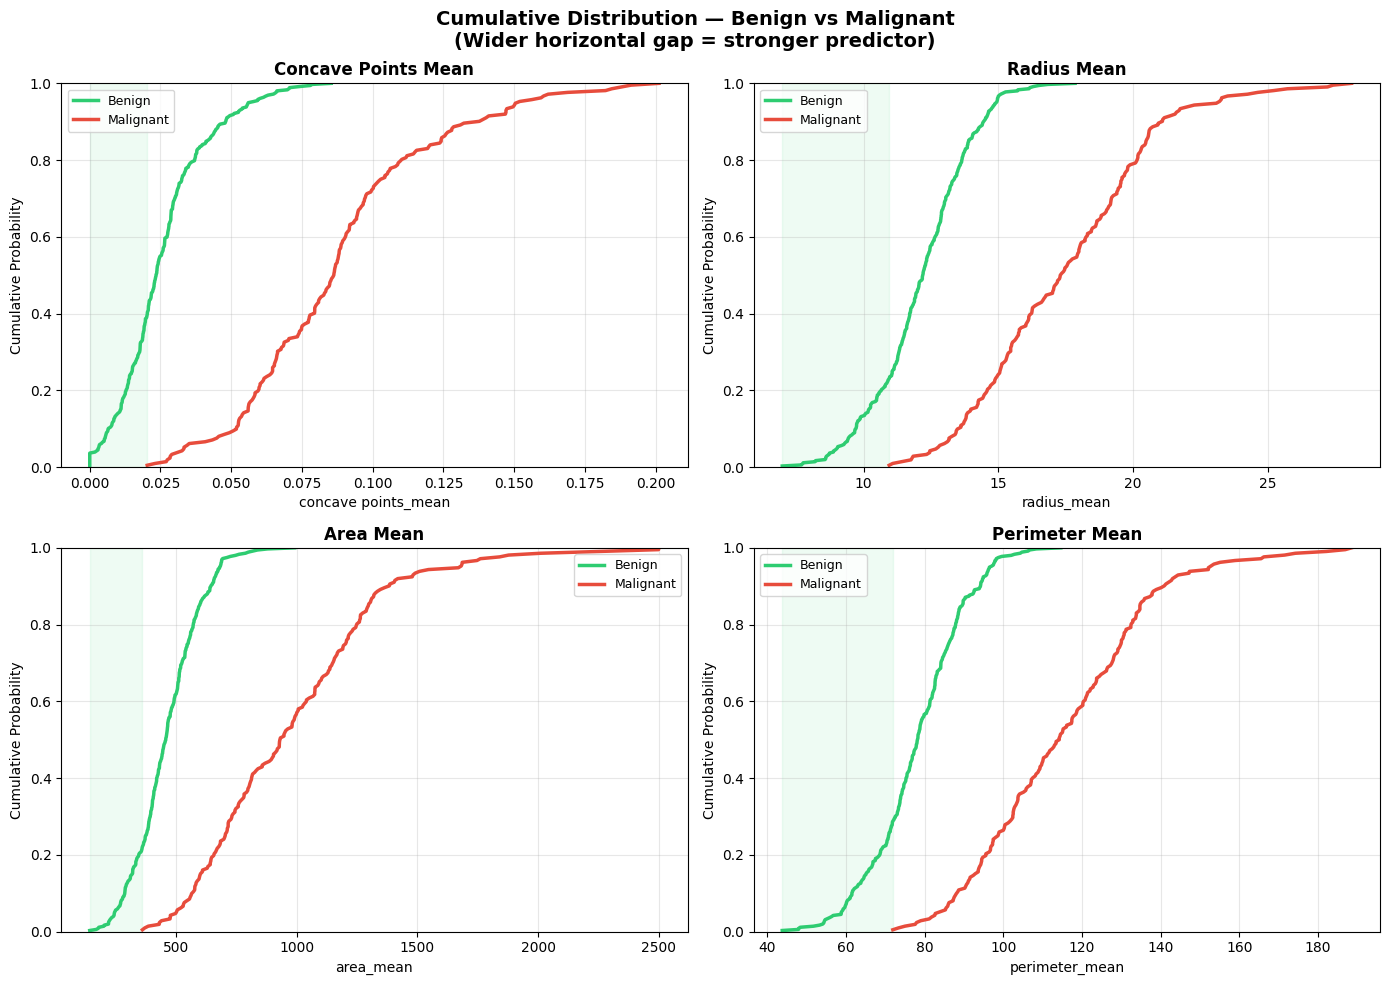

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

features = ['concave points_mean', 'radius_mean', 'area_mean', 'perimeter_mean']

for i, feature in enumerate(features):
    benign_vals = df[df['diagnosis']=='B'][feature].sort_values()
    malignant_vals = df[df['diagnosis']=='M'][feature].sort_values()

    # calculate CDF
    benign_cdf = np.arange(1, len(benign_vals)+1) / len(benign_vals)
    malignant_cdf = np.arange(1, len(malignant_vals)+1) / len(malignant_vals)

    axes[i].plot(benign_vals, benign_cdf, color='#2ecc71',
                 linewidth=2.5, label='Benign')
    axes[i].plot(malignant_vals, malignant_cdf, color='#e74c3c',
                 linewidth=2.5, label='Malignant')

    # shade the gap between curves
    axes[i].fill_betweenx([0, 1],
                           benign_vals.min(), malignant_vals.min(),
                           alpha=0.08, color='#2ecc71')

    axes[i].set_title(feature.replace('_', ' ').title(),
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Cumulative Probability')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)
    axes[i].set_ylim(0, 1)

fig.suptitle('Cumulative Distribution — Benign vs Malignant\n(Wider horizontal gap = stronger predictor)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/cdf_top_features.png', dpi=150)
plt.show()

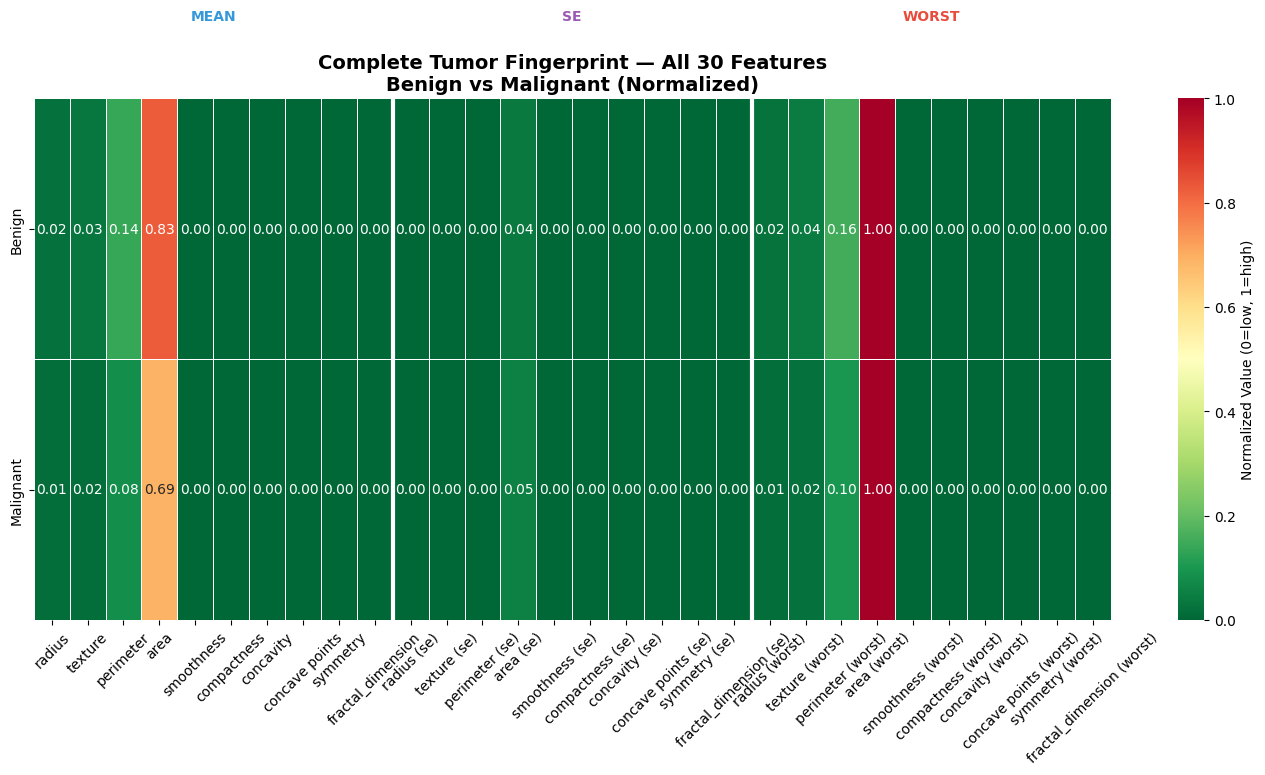

In [32]:
fig, ax = plt.subplots(figsize=(14, 8))

from sklearn.preprocessing import MinMaxScaler

# get all 30 features
all_features = [c for c in df.columns if '_mean' in c or '_se' in c or '_worst' in c]

# calculate mean per diagnosis
profile = df.groupby('diagnosis')[all_features].mean()

# normalize across each feature (column-wise)
scaler = MinMaxScaler()
profile_scaled = pd.DataFrame(
    scaler.fit_transform(profile.T).T,
    index=profile.index,
    columns=profile.columns
)

# organize columns by category
mean_cols  = [c for c in all_features if '_mean' in c]
se_cols    = [c for c in all_features if '_se' in c]
worst_cols = [c for c in all_features if '_worst' in c]
ordered_cols = mean_cols + se_cols + worst_cols

profile_scaled = profile_scaled[ordered_cols]

# clean column labels
clean_labels = [c.replace('_mean','').replace('_se',' (se)').replace('_worst',' (worst)')
                for c in ordered_cols]

sns.heatmap(profile_scaled, annot=True, fmt='.2f',
            cmap='RdYlGn_r', linewidths=0.5,
            xticklabels=clean_labels,
            yticklabels=['Benign', 'Malignant'],
            ax=ax, cbar_kws={'label': 'Normalized Value (0=low, 1=high)'})

ax.set_title('Complete Tumor Fingerprint — All 30 Features\nBenign vs Malignant (Normalized)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)

# add category dividers
ax.axvline(x=10, color='white', linewidth=3)
ax.axvline(x=20, color='white', linewidth=3)
ax.text(5, -0.3, 'MEAN', ha='center', fontsize=10,
        fontweight='bold', color='#3498db', transform=ax.transData)
ax.text(15, -0.3, 'SE', ha='center', fontsize=10,
        fontweight='bold', color='#9b59b6', transform=ax.transData)
ax.text(25, -0.3, 'WORST', ha='center', fontsize=10,
        fontweight='bold', color='#e74c3c', transform=ax.transData)

plt.tight_layout()
plt.savefig('visualizations/tumor_fingerprint_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

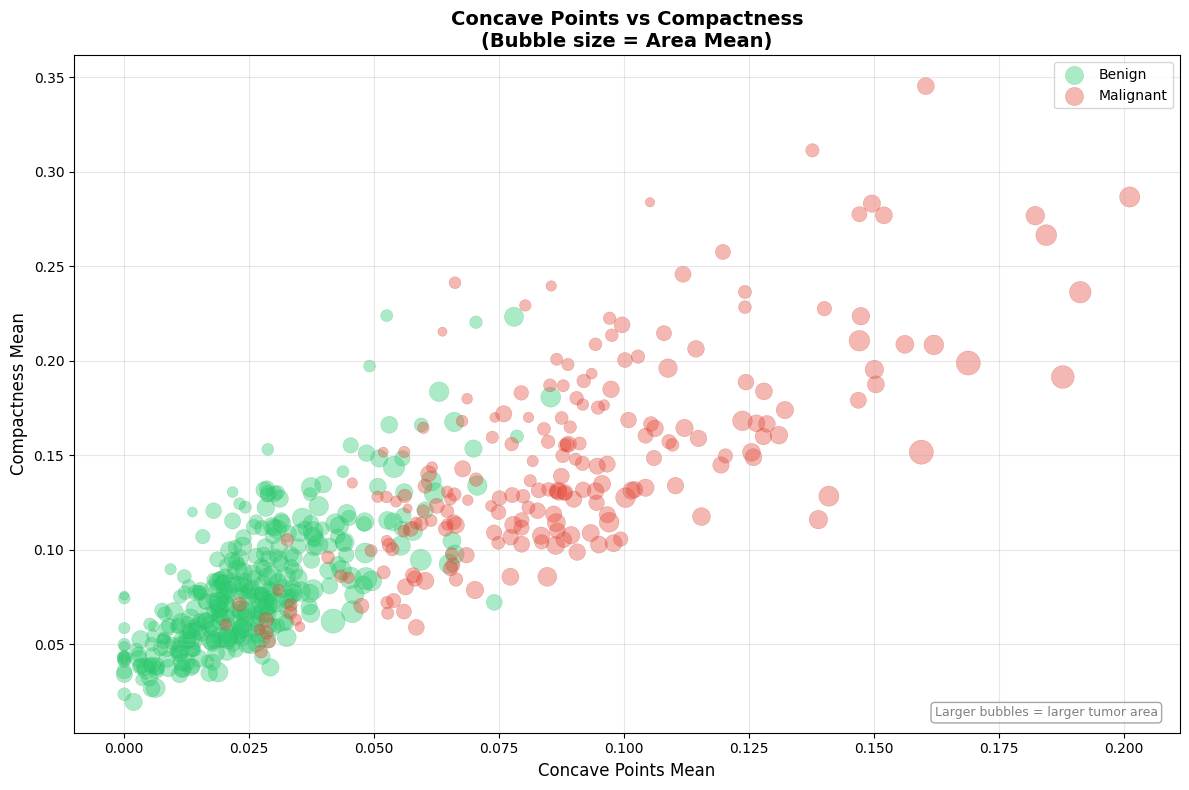

In [33]:
fig, ax = plt.subplots(figsize=(12, 8))

benign = df[df['diagnosis'] == 'B']
malignant = df[df['diagnosis'] == 'M']

# bubble size scaled by area_mean
benign_size = (benign['area_mean'] / benign['area_mean'].max()) * 300
malignant_size = (malignant['area_mean'] / malignant['area_mean'].max()) * 300

ax.scatter(benign['concave points_mean'],
           benign['compactness_mean'],
           s=benign_size, c='#2ecc71', alpha=0.4,
           edgecolors='#27ae60', linewidth=0.3,
           label='Benign')

ax.scatter(malignant['concave points_mean'],
           malignant['compactness_mean'],
           s=malignant_size, c='#e74c3c', alpha=0.4,
           edgecolors='#c0392b', linewidth=0.3,
           label='Malignant')

ax.set_xlabel('Concave Points Mean', fontsize=12)
ax.set_ylabel('Compactness Mean', fontsize=12)
ax.set_title('Concave Points vs Compactness\n(Bubble size = Area Mean)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# add annotation
ax.annotate('Larger bubbles = larger tumor area',
            xy=(0.98, 0.02), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=9,
            color='gray',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='white', edgecolor='gray', alpha=0.7))

plt.tight_layout()
plt.savefig('visualizations/bubble_chart.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/580784284.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='diagnosis', y=feature,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/580784284.py:32: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(['Benign', 'Malignant'])
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/580784284.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='diagnosis', y=feature,
/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/580784284.py:32: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[

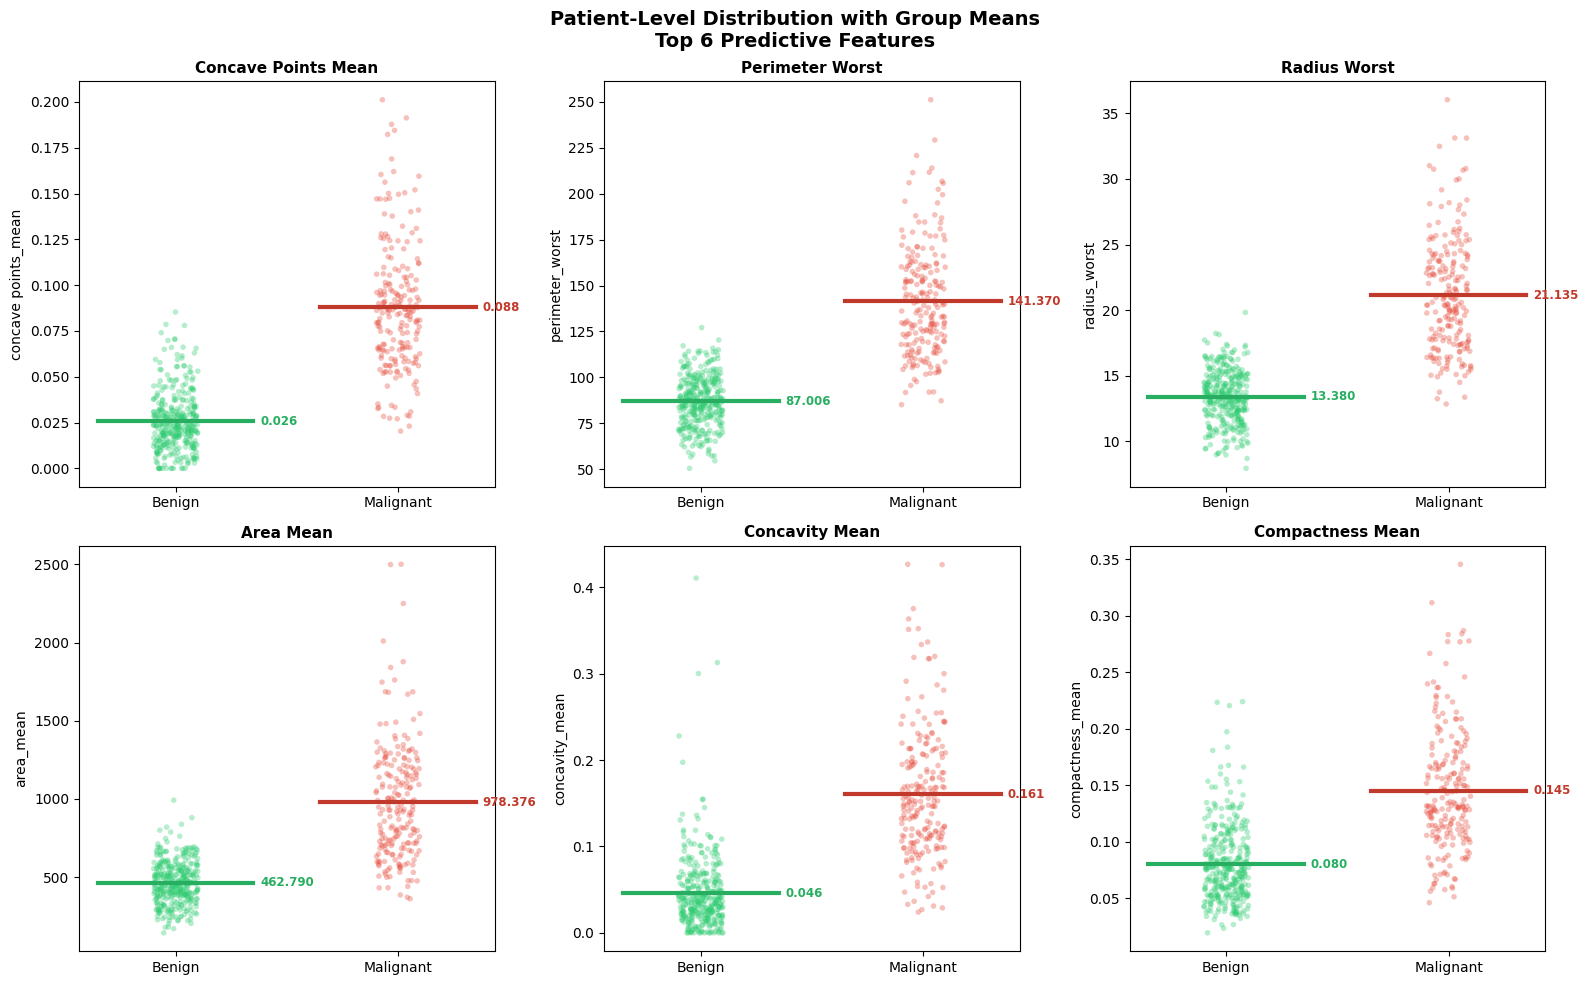

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

top6_features = [
    'concave points_mean',
    'perimeter_worst',
    'radius_worst',
    'area_mean',
    'concavity_mean',
    'compactness_mean'
]

for i, feature in enumerate(top6_features):
    # strip plot — every patient as a dot
    sns.stripplot(data=df, x='diagnosis', y=feature,
                  palette={'M': '#e74c3c', 'B': '#2ecc71'},
                  alpha=0.35, size=4, jitter=True,
                  order=['B', 'M'], ax=axes[i])

    # overlay group mean as a bold horizontal line
    for j, (diag, color) in enumerate([('B', '#27ae60'), ('M', '#c0392b')]):
        mean_val = df[df['diagnosis'] == diag][feature].mean()
        axes[i].plot([j - 0.35, j + 0.35], [mean_val, mean_val],
                     color=color, linewidth=3, zorder=5)
        axes[i].text(j + 0.38, mean_val, f'{mean_val:.3f}',
                     va='center', fontsize=8.5,
                     fontweight='bold', color=color)

    axes[i].set_title(feature.replace('_', ' ').title(),
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Benign', 'Malignant'])

fig.suptitle('Patient-Level Distribution with Group Means\nTop 6 Predictive Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/strip_plot_with_means.png', dpi=150)
plt.show()

/var/folders/3x/r8c2gxtj63bb36xdz4fz55xc0000gp/T/ipykernel_2232/1982256040.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_yticklabels([f.replace('_mean','').replace('_worst',' (w)').replace('_se',' (se)')


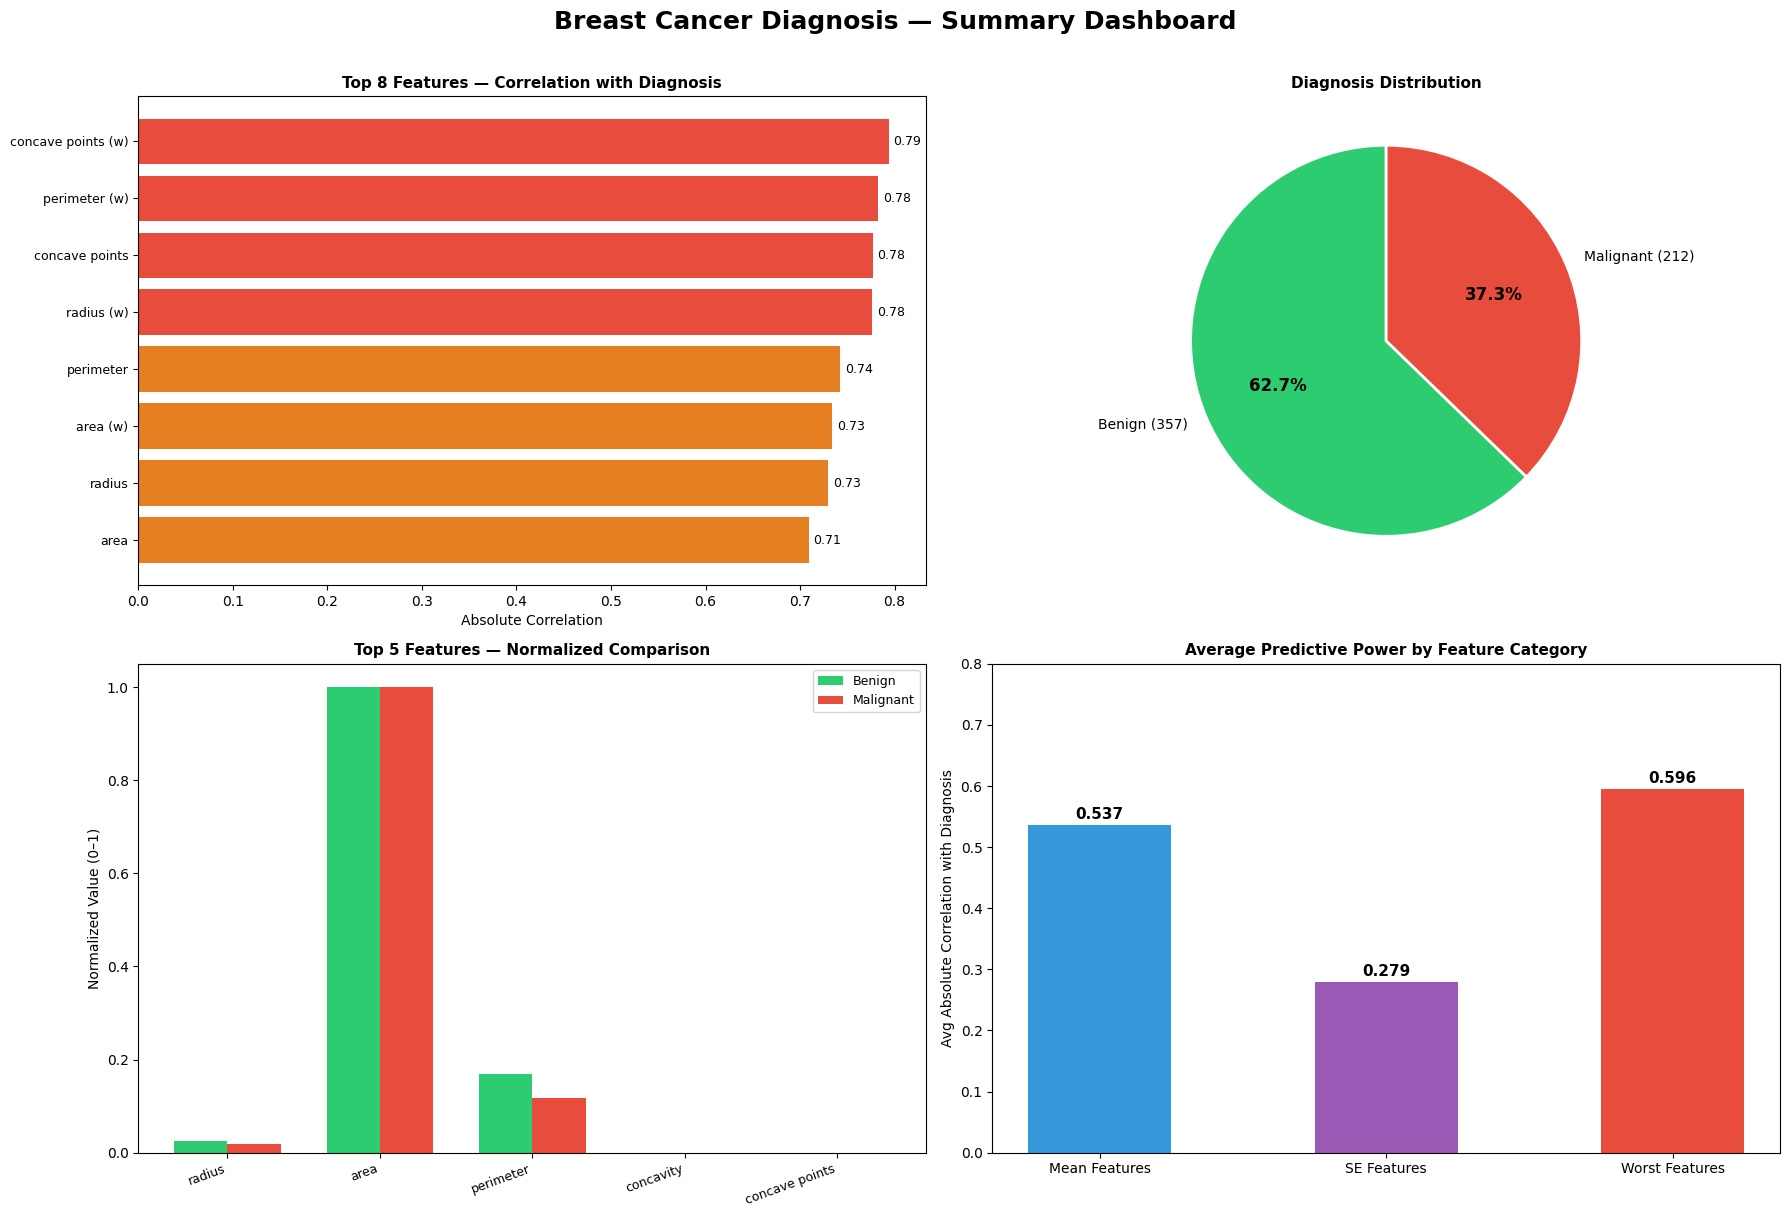

In [36]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Breast Cancer Diagnosis — Summary Dashboard',
             fontsize=18, fontweight='bold', y=1.01)

# ── 1. Top 8 feature correlations (top left) ──────────────────
ax1 = fig.add_subplot(2, 2, 1)

all_features = [c for c in df.columns if '_mean' in c or '_worst' in c or '_se' in c]
corr = df[all_features].corrwith(df['diagnosis_encoded']).abs()
corr = corr.drop('diagnosis_encoded', errors='ignore')
top8 = corr.sort_values(ascending=False).head(8)

colors = ['#e74c3c' if v > 0.75 else '#e67e22' if v > 0.60 else '#3498db'
          for v in top8.values]
bars = ax1.barh(top8.index, top8.values, color=colors)
ax1.set_title('Top 8 Features — Correlation with Diagnosis',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Absolute Correlation')
ax1.invert_yaxis()
ax1.set_yticklabels([f.replace('_mean','').replace('_worst',' (w)').replace('_se',' (se)')
                     for f in top8.index], fontsize=9)
for bar, val in zip(bars, top8.values):
    ax1.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9)

# ── 2. Diagnosis distribution (top right) ─────────────────────
ax2 = fig.add_subplot(2, 2, 2)

counts = df['diagnosis'].value_counts()
wedges, texts, autotexts = ax2.pie(
    counts.values,
    labels=['Benign (357)', 'Malignant (212)'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in autotexts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
ax2.set_title('Diagnosis Distribution',
              fontsize=11, fontweight='bold')

# ── 3. Key mean stats comparison (bottom left) ────────────────
ax3 = fig.add_subplot(2, 2, 3)

top5 = ['radius_mean', 'area_mean', 'perimeter_mean',
        'concavity_mean', 'concave points_mean']
benign_means = df[df['diagnosis']=='B'][top5].mean()
malignant_means = df[df['diagnosis']=='M'][top5].mean()

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
all_means = np.vstack([benign_means.values, malignant_means.values])
normalized = scaler.fit_transform(all_means.T).T
b_norm, m_norm = normalized[0], normalized[1]

x = np.arange(len(top5))
width = 0.35
ax3.bar(x - width/2, b_norm, width, color='#2ecc71', label='Benign')
ax3.bar(x + width/2, m_norm, width, color='#e74c3c', label='Malignant')
ax3.set_xticks(x)
ax3.set_xticklabels([f.replace('_mean','') for f in top5],
                    rotation=20, ha='right', fontsize=9)
ax3.set_title('Top 5 Features — Normalized Comparison',
              fontsize=11, fontweight='bold')
ax3.set_ylabel('Normalized Value (0–1)')
ax3.legend(fontsize=9)

# ── 4. Category predictive power (bottom right) ───────────────
ax4 = fig.add_subplot(2, 2, 4)

mean_avg  = df[[c for c in df.columns if '_mean' in c]].corrwith(df['diagnosis_encoded']).abs().mean()
se_avg    = df[[c for c in df.columns if '_se' in c]].corrwith(df['diagnosis_encoded']).abs().mean()
worst_avg = df[[c for c in df.columns if '_worst' in c]].corrwith(df['diagnosis_encoded']).abs().mean()

categories = ['Mean Features', 'SE Features', 'Worst Features']
values = [mean_avg, se_avg, worst_avg]
bar_colors = ['#3498db', '#9b59b6', '#e74c3c']

bars = ax4.bar(categories, values, color=bar_colors, width=0.5)
ax4.set_title('Average Predictive Power by Feature Category',
              fontsize=11, fontweight='bold')
ax4.set_ylabel('Avg Absolute Correlation with Diagnosis')
ax4.set_ylim(0, 0.8)

for bar, val in zip(bars, values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

### End of the project